In [ ]:
!pip install -q transformers sentencepiece accelerate scikit-learn matplotlib wordcloud h5py onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 112.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 137.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os
import re
import json
import random
import shutil
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from wordcloud import WordCloud

from google.colab import files

In [ ]:
# CONFIG

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

TEXT_COL = "teks"
LABEL_COL = "label"

GROUP_COL = None

# Label:
# human = 0
# ai    = 1

# Output path
DRIVE_ROOT = Path("/content/drive/MyDrive/Deep-Learning/AOL_II/Results3")
OUTPUT_ROOT = DRIVE_ROOT / "HumanVsAI_Text-Classification"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

EDA_DIR = OUTPUT_ROOT / "eda"
EDA_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ARTIFACT_DIR = OUTPUT_ROOT / "model_artifacts"
MODEL_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

COMPARISON_DIR = OUTPUT_ROOT / "model_comparison"
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

REPRESENTATION_DIR = OUTPUT_ROOT / "feature_representation"
REPRESENTATION_DIR.mkdir(parents=True, exist_ok=True)

LEAKAGE_DIR = OUTPUT_ROOT / "leakage_check"
LEAKAGE_DIR.mkdir(parents=True, exist_ok=True)

print("All outputs will be saved to:")
print(OUTPUT_ROOT)

# Model names
INDOBERT_MODEL_NAME = "indobenchmark/indobert-base-p2"
XLMR_MODEL_NAME = "xlm-roberta-base"

# Transformer config
TRANSFORMER_MAX_LEN = 192 # Batch size dan epoch untuk IndoBERT dan XLM-RoBERTa dibuat sama
TRANSFORMER_BATCH_SIZE = 16
TRANSFORMER_EPOCHS = 3
TRANSFORMER_LR = 2e-5

# BiLSTM config
BILSTM_MAX_LEN = 192
BILSTM_BATCH_SIZE = 32
BILSTM_EPOCHS = 15
BILSTM_LR = 2e-4

HIDDEN_DIM = 64
NUM_LAYERS = 1
DROPOUT = 0.5
BILSTM_WEIGHT_DECAY = 0.05
MAX_VOCAB_SIZE = 30000
MIN_FREQ = 2

# Early stopping
EARLY_STOPPING_PATIENCE_BILSTM = 3
MIN_DELTA = 1e-4

FREEZE_EMBEDDING = False

# FastText Indonesian pretrained embedding
EMBEDDING_DIR = Path("/content/embeddings")
EMBEDDING_DIR.mkdir(parents=True, exist_ok=True)

FASTTEXT_PATH = EMBEDDING_DIR / "cc.id.300.vec.gz"

PRETRAINED_EMBEDDING_PATH = str(FASTTEXT_PATH)

FREEZE_EMBEDDING = False

print("FastText session path:", PRETRAINED_EMBEDDING_PATH)
print("Freeze embedding:", FREEZE_EMBEDDING)

# Shared config

NUM_LABELS = 2
WEIGHT_DECAY = 0.01

# Class weight hanya digunakan jika rasio kelas tidak seimbang.
# Jika gap rasio <= 0.10, class weight tidak digunakan.
IMBALANCE_THRESHOLD = 0.10

# Near duplicate threshold
NEAR_DUPLICATE_THRESHOLD = 0.95

Device: cuda
All outputs will be saved to:
/content/drive/MyDrive/Deep-Learning/AOL_II/Results3/HumanVsAI_Text-Classification
FastText session path: /content/embeddings/cc.id.300.vec.gz
Freeze embedding: False


In [ ]:
# UPLOAD CSV

uploaded = files.upload()
csv_path = list(uploaded.keys())[0]

try:
    df = pd.read_csv(
        csv_path,
        encoding="utf-8",
        quotechar='"',
        escapechar="\\",
        on_bad_lines="skip"
    )
except UnicodeDecodeError:
    df = pd.read_csv(
        csv_path,
        encoding="utf-8-sig",
        quotechar='"',
        escapechar="\\",
        on_bad_lines="skip"
    )

print("Uploaded:", csv_path)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

df.head()

Saving test-news-speech.csv to test-news-speech (1).csv
Uploaded: test-news-speech (1).csv
Shape: (3998, 2)
Columns: ['teks', 'label']


,teks,label
0,"Pada hari pertama seleksi nasional, para peser...",1
1,"Dalam Seleknas tahap awal ini, akan dipilih 18...",1
2,"Sama halnya dengan basket, seleksi tenis meja ...",1
3,"Farid Rahman, Sekretaris Jenderal Pengurus Bes...",1
4,Farid menyampaikan bahwa dalam waktu dekat aka...,1


## EDA

In [ ]:
# DATA VALIDATION

if TEXT_COL not in df.columns:
    raise ValueError(f"Kolom teks '{TEXT_COL}' tidak ditemukan. Kolom tersedia: {df.columns.tolist()}")

if LABEL_COL not in df.columns:
    raise ValueError(f"Kolom label '{LABEL_COL}' tidak ditemukan. Kolom tersedia: {df.columns.tolist()}")

if GROUP_COL is not None and GROUP_COL not in df.columns:
    raise ValueError(f"GROUP_COL '{GROUP_COL}' tidak ditemukan. Kolom tersedia: {df.columns.tolist()}")

required_cols = [TEXT_COL, LABEL_COL]

if GROUP_COL is not None:
    required_cols.append(GROUP_COL)

df = df[required_cols].copy()

df = df.dropna(subset=[TEXT_COL, LABEL_COL])
df[TEXT_COL] = df[TEXT_COL].astype(str)

def normalize_label(x):
    if isinstance(x, str):
        x = x.strip().lower()
        if x in ["human", "manusia", "0"]:
            return 0
        elif x in ["ai", "machine", "generated", "1"]:
            return 1
    return int(x)

df[LABEL_COL] = df[LABEL_COL].apply(normalize_label)
df[LABEL_COL] = df[LABEL_COL].astype(int)

df = df[df[LABEL_COL].isin([0, 1])].copy()

before = len(df)
df = df.drop_duplicates(subset=[TEXT_COL]).reset_index(drop=True)
after = len(df)

print("Removed exact duplicate texts:", before - after)
print("Final shape:", df.shape)
print(df[LABEL_COL].value_counts())

df.head()

Removed exact duplicate texts: 0
Final shape: (3998, 2)
label
0    2000
1    1998
Name: count, dtype: int64


,teks,label
0,"Pada hari pertama seleksi nasional, para peser...",1
1,"Dalam Seleknas tahap awal ini, akan dipilih 18...",1
2,"Sama halnya dengan basket, seleksi tenis meja ...",1
3,"Farid Rahman, Sekretaris Jenderal Pengurus Bes...",1
4,Farid menyampaikan bahwa dalam waktu dekat aka...,1


In [ ]:
# BASIC EDA

STOPWORDS_ID = set("""
yang dan di ke dari ini itu untuk dengan pada adalah dalam sebagai karena atau juga
akan tidak lebih dapat telah bisa oleh sangat agar yaitu namun serta antara menjadi
sebuah tersebut mereka kita saya kamu dia ia ada para tanpa hingga terhadap tentang
""".split())

def simple_tokenize(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+|#\w+", " ", text)
    text = re.sub(r"[^a-zA-ZÀ-ÿ0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

df["word_count"] = df[TEXT_COL].apply(lambda x: len(simple_tokenize(x)))
df["char_count"] = df[TEXT_COL].apply(lambda x: len(str(x)))

print(df[["word_count", "char_count"]].describe())

        word_count   char_count
count  3998.000000  3998.000000
mean     66.406703   450.389695
std      26.974384   165.544556
min      10.000000    74.000000
25%      44.000000   318.000000
50%      62.000000   441.000000
75%      97.000000   604.000000
max     202.000000  1350.000000


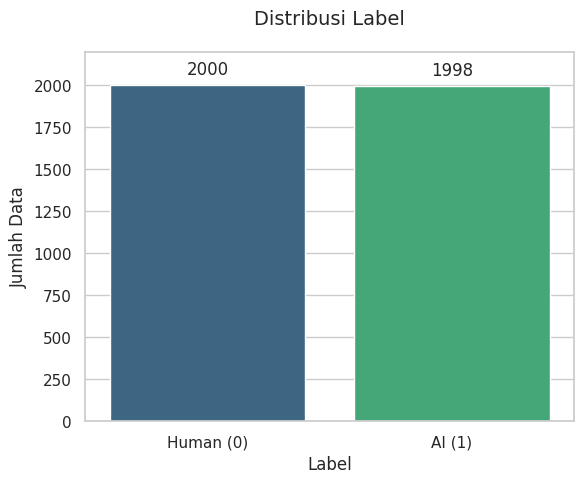

In [ ]:
# LABEL DISTRIBUTION

import seaborn as sns

label_counts = df[LABEL_COL].value_counts().sort_index()

dist_df = pd.DataFrame({
    "Label": ["Human (0)", "AI (1)"],
    "Jumlah": [
        label_counts.get(0, 0),
        label_counts.get(1, 0)
    ]
})

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 5))

ax = sns.barplot(
    data=dist_df,
    x="Label",
    y="Jumlah",
    hue="Label",
    legend=False,
    palette="viridis"
)

plt.title("Distribusi Label", fontsize=14, pad=20)
plt.xlabel("Label")
plt.ylabel("Jumlah Data")

max_jumlah = dist_df["Jumlah"].max()
plt.ylim(0, max_jumlah * 1.1 if max_jumlah > 0 else 1)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points"
    )

plt.tight_layout()
plt.savefig(EDA_DIR / "label_distribution.png", dpi=300)
plt.show()

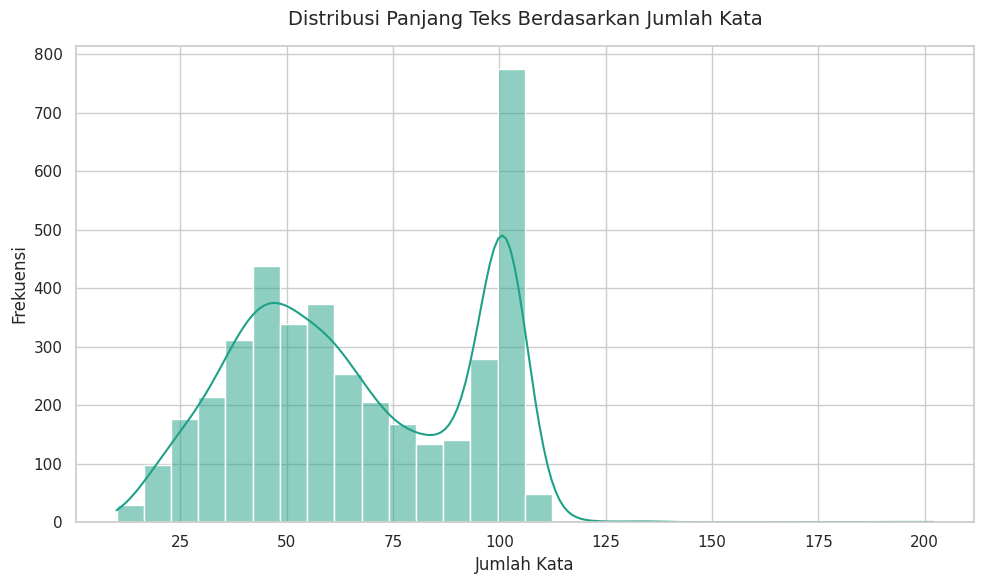

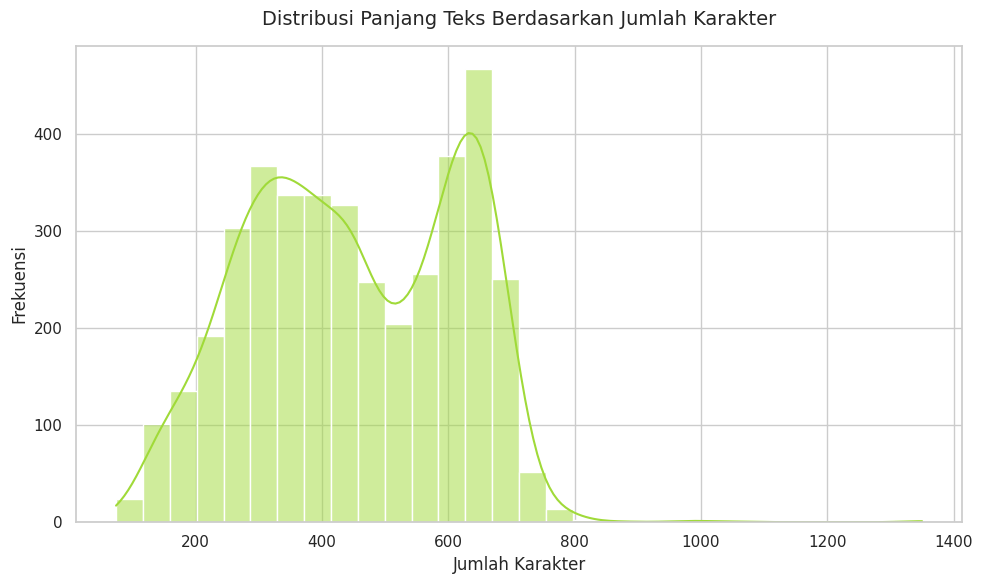

In [ ]:
# DISTRIBUTION BY WORD COUNT
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="word_count",
    bins=30,
    kde=True,
    color=sns.color_palette("viridis")[3],
    edgecolor="white"
)

plt.title("Distribusi Panjang Teks Berdasarkan Jumlah Kata", fontsize=14, pad=15)
plt.xlabel("Jumlah Kata", fontsize=12)
plt.ylabel("Frekuensi", fontsize=12)

plt.tight_layout()
plt.savefig(EDA_DIR / "word_count_distribution.png", dpi=300)
plt.show()
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="char_count",
    bins=30,
    kde=True,
    color=sns.color_palette("viridis")[5],
    edgecolor="white"
)

plt.title("Distribusi Panjang Teks Berdasarkan Jumlah Karakter", fontsize=14, pad=15)
plt.xlabel("Jumlah Karakter", fontsize=12)
plt.ylabel("Frekuensi", fontsize=12)

plt.tight_layout()
plt.savefig(EDA_DIR / "char_count_distribution.png", dpi=300)
plt.show()

/tmp/ipykernel_1596/2883787158.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([human_lengths, ai_lengths], labels=["Human", "AI"])


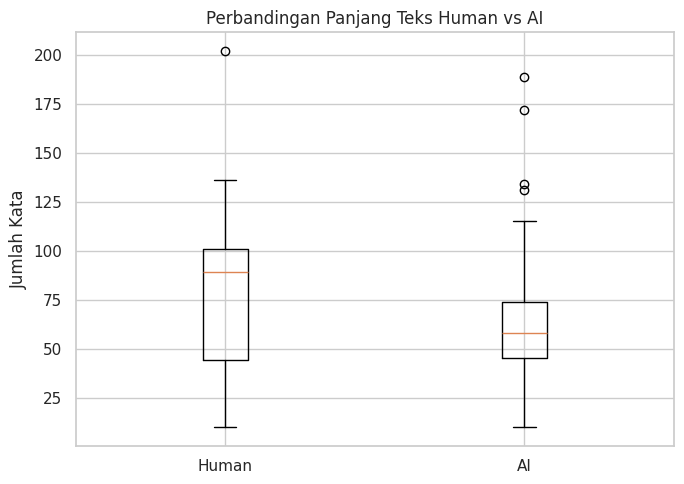

In [ ]:
# TEXT LENGTH BY LABEL

human_lengths = df[df[LABEL_COL] == 0]["word_count"]
ai_lengths = df[df[LABEL_COL] == 1]["word_count"]

plt.figure(figsize=(7, 5))
plt.boxplot([human_lengths, ai_lengths], labels=["Human", "AI"])
plt.title("Perbandingan Panjang Teks Human vs AI")
plt.ylabel("Jumlah Kata")
plt.tight_layout()
plt.savefig(EDA_DIR / "word_count_by_label_boxplot.png", dpi=300)
plt.show()

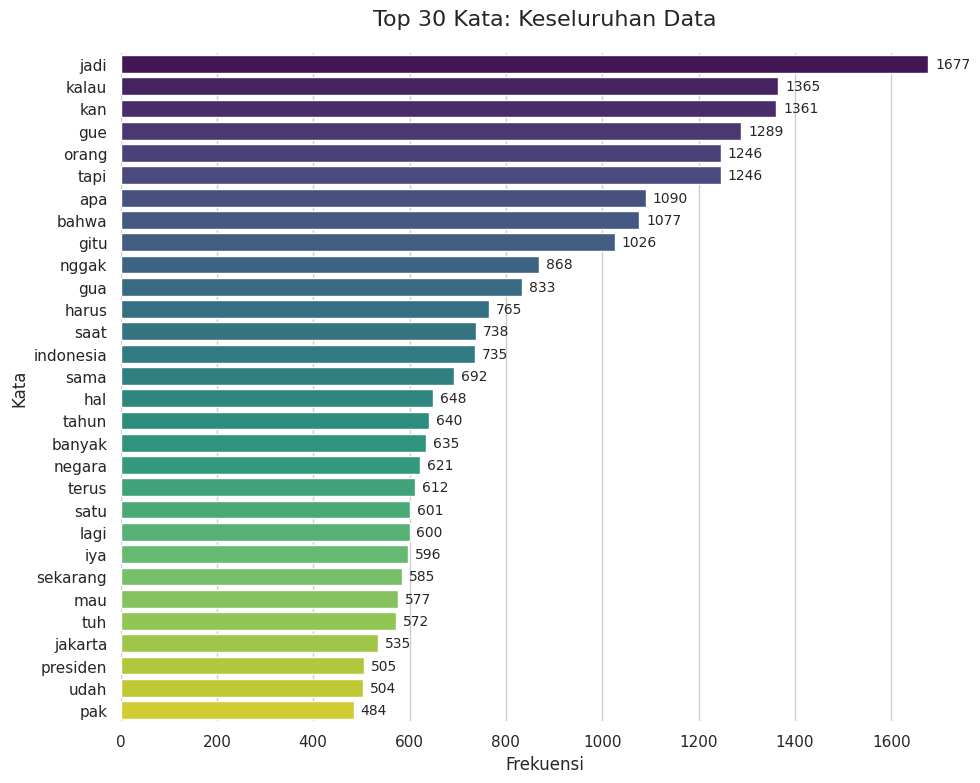

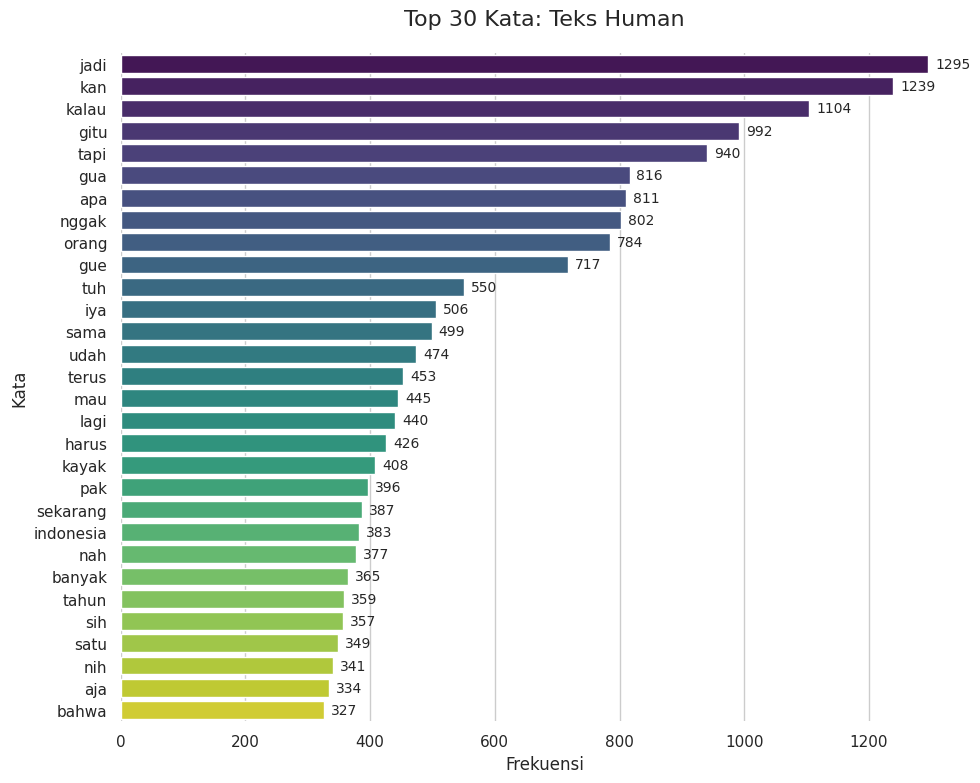

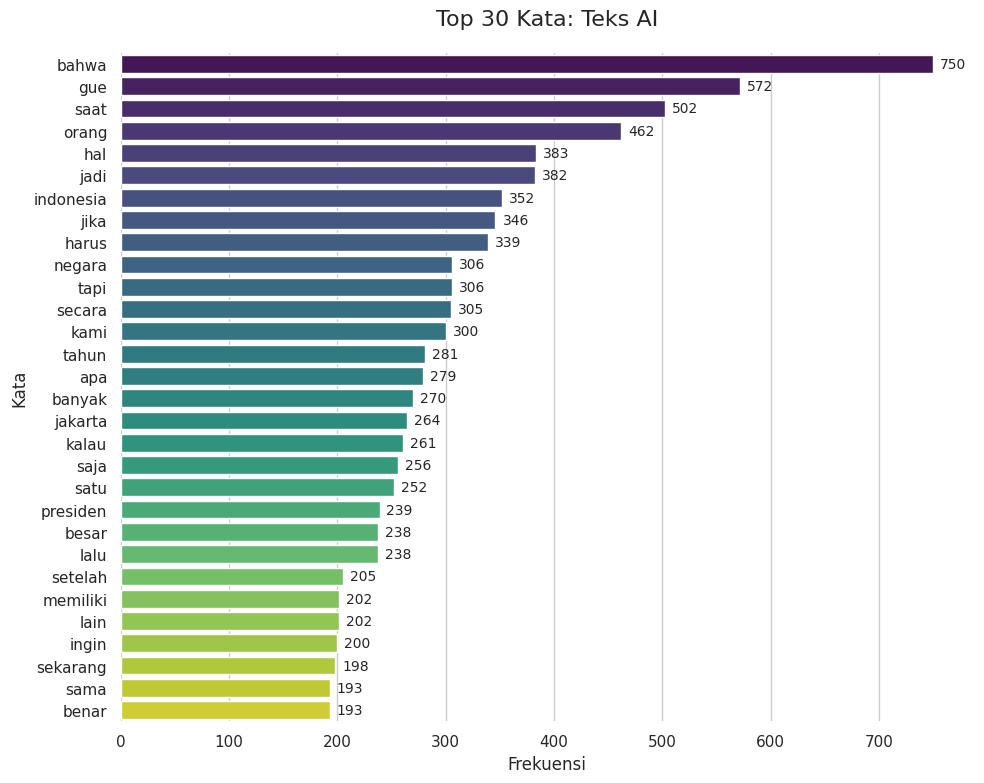

In [ ]:
# MOST COMMON WORDS

STOPWORDS_ID = set("""
yang dan di ke dari ini itu untuk dengan pada adalah dalam sebagai karena atau juga
akan tidak lebih dapat telah bisa oleh sangat agar yaitu namun serta antara menjadi
sebuah tersebut mereka kita saya kamu dia ia ada para tanpa hingga terhadap tentang
dengan kepada bagi demi sejak sampai seperti bukan sudah belum masih hanya
""".split())


def simple_tokenize(text):
    """
    Tokenisasi sederhana untuk EDA.
    Tidak digunakan untuk preprocessing Transformer.
    """
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+|#\w+", " ", text)
    text = re.sub(r"[^a-zA-ZÀ-ÿ0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()


def get_common_words(texts, top_n=30, remove_stopwords=True):
    """
    Mengambil kata paling sering muncul.

    remove_stopwords=True:
    stopwords dihapus agar kata informatif lebih terlihat di EDA.
    """
    all_tokens = []

    for text in texts:
        tokens = simple_tokenize(text)

        if remove_stopwords:
            tokens = [
                t for t in tokens
                if t not in STOPWORDS_ID and len(t) > 2
            ]

        all_tokens.extend(tokens)

    return Counter(all_tokens).most_common(top_n)


def plot_common_words(common_words, title, save_path):
    if len(common_words) == 0:
        print(f"Tidak ada kata untuk divisualisasikan: {title}")
        return

    words = [w for w, c in common_words]
    counts = [c for w, c in common_words]

    plt.figure(figsize=(10, 8))
    ax = sns.barplot(
        x=counts,
        y=words,
        palette="viridis",
        hue=words,
        legend=False
    )

    for p in ax.patches:
        ax.annotate(
            f"{int(p.get_width())}",
            (p.get_width(), p.get_y() + p.get_height() / 2),
            ha="left",
            va="center",
            xytext=(5, 0),
            textcoords="offset points",
            fontsize=10
        )

    plt.title(title, fontsize=16, pad=20)
    plt.xlabel("Frekuensi", fontsize=12)
    plt.ylabel("Kata", fontsize=12)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()


sns.set_theme(style="whitegrid")

# Dengan stopword removal untuk EDA
common_all = get_common_words(df[TEXT_COL], top_n=30, remove_stopwords=True)
common_human = get_common_words(
    df[df[LABEL_COL] == 0][TEXT_COL],
    top_n=30,
    remove_stopwords=True
)
common_ai = get_common_words(
    df[df[LABEL_COL] == 1][TEXT_COL],
    top_n=30,
    remove_stopwords=True
)

plot_common_words(
    common_all,
    "Top 30 Kata: Keseluruhan Data",
    EDA_DIR / "top_words_all.png"
)

plot_common_words(
    common_human,
    "Top 30 Kata: Teks Human",
    EDA_DIR / "top_words_human.png"
)

plot_common_words(
    common_ai,
    "Top 30 Kata: Teks AI",
    EDA_DIR / "top_words_ai.png"
)

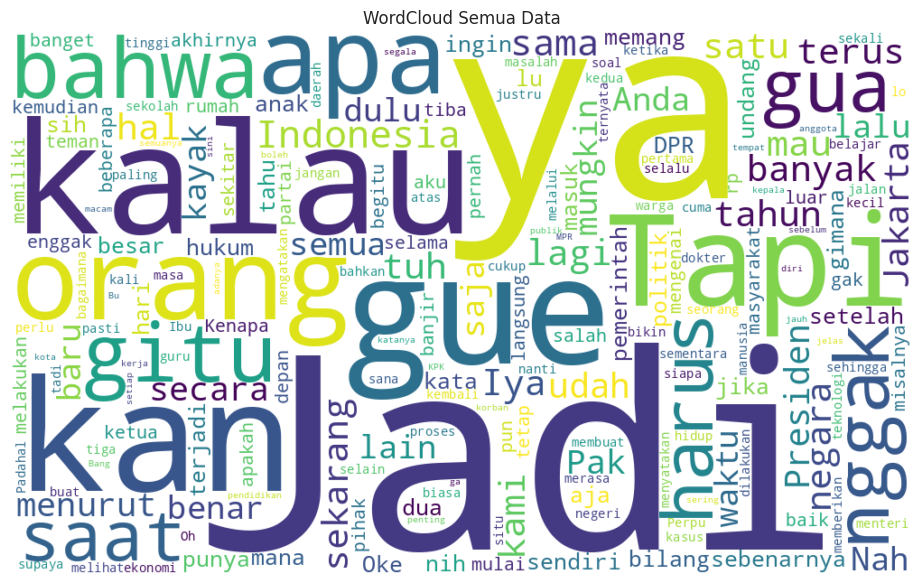

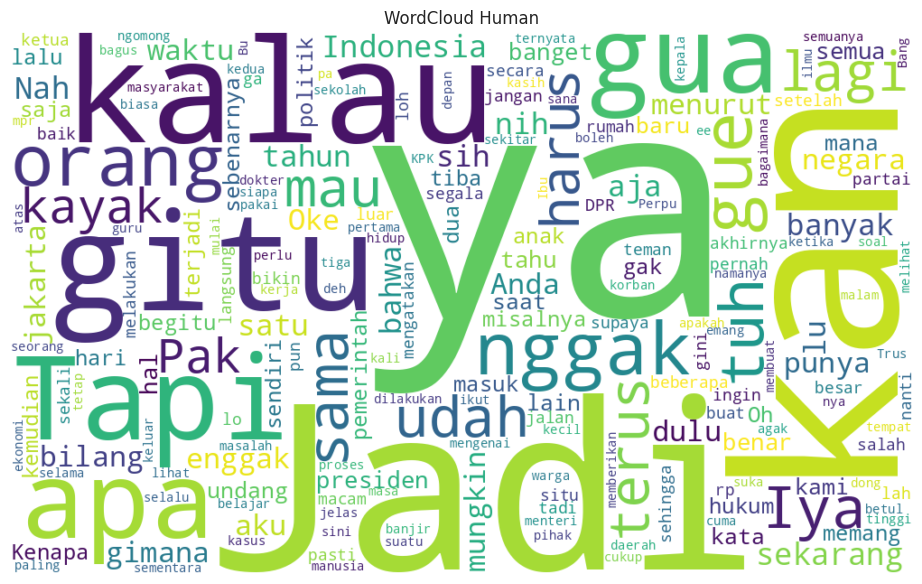

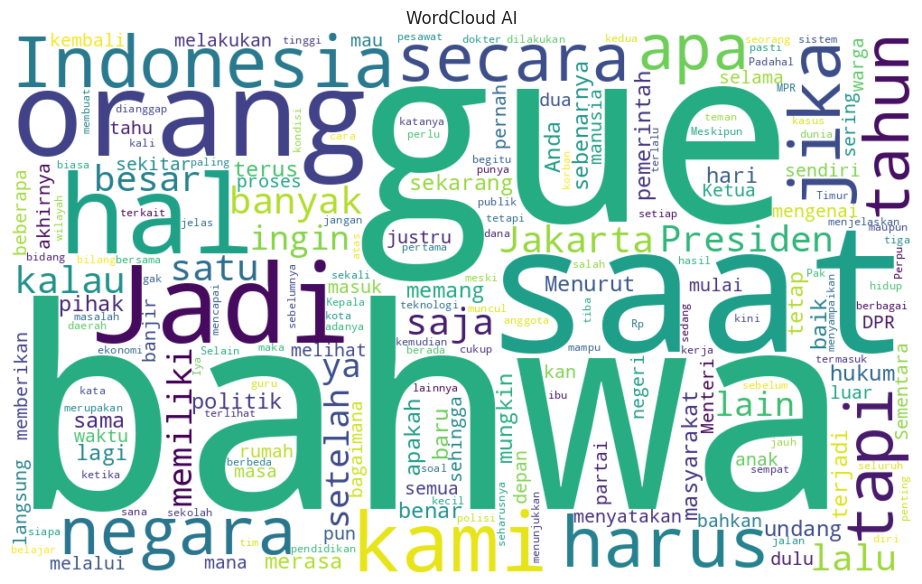

In [ ]:
# WORDCLOUD

def make_wordcloud(texts, title, save_path):
    combined = " ".join(texts.astype(str).tolist())

    wc = WordCloud(
        width=1000,
        height=600,
        background_color="white",
        stopwords=STOPWORDS_ID,
        collocations=False
    ).generate(combined)

    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

make_wordcloud(df[TEXT_COL], "WordCloud Semua Data", EDA_DIR / "wordcloud_all.png")
make_wordcloud(df[df[LABEL_COL] == 0][TEXT_COL], "WordCloud Human", EDA_DIR / "wordcloud_human.png")
make_wordcloud(df[df[LABEL_COL] == 1][TEXT_COL], "WordCloud AI", EDA_DIR / "wordcloud_ai.png")

## TRAINING

In [ ]:
# TRAIN / VALIDATION / TEST SPLIT -> 70/15/15

if GROUP_COL is None:
    train_df, temp_df = train_test_split(
        df,
        test_size=0.30,
        random_state=SEED,
        stratify=df[LABEL_COL]
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=SEED,
        stratify=temp_df[LABEL_COL]
    )

else:
    from sklearn.model_selection import StratifiedGroupKFold

    X = df[TEXT_COL]
    y = df[LABEL_COL]
    groups = df[GROUP_COL]

    sgkf_1 = StratifiedGroupKFold(
        n_splits=10,
        shuffle=True,
        random_state=SEED
    )

    train_idx, temp_idx = next(sgkf_1.split(X, y, groups))

    train_df = df.iloc[train_idx].reset_index(drop=True)
    temp_df = df.iloc[temp_idx].reset_index(drop=True)

    sgkf_2 = StratifiedGroupKFold(
        n_splits=2,
        shuffle=True,
        random_state=SEED
    )

    X_temp = temp_df[TEXT_COL]
    y_temp = temp_df[LABEL_COL]
    groups_temp = temp_df[GROUP_COL]

    val_idx, test_idx = next(sgkf_2.split(X_temp, y_temp, groups_temp))

    val_df = temp_df.iloc[val_idx].reset_index(drop=True)
    test_df = temp_df.iloc[test_idx].reset_index(drop=True)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape, train_df[LABEL_COL].value_counts().to_dict())
print("Val  :", val_df.shape, val_df[LABEL_COL].value_counts().to_dict())
print("Test :", test_df.shape, test_df[LABEL_COL].value_counts().to_dict())

train_df.to_csv(OUTPUT_ROOT / "train_split.csv", index=False)
val_df.to_csv(OUTPUT_ROOT / "val_split.csv", index=False)
test_df.to_csv(OUTPUT_ROOT / "test_split.csv", index=False)

Train: (2798, 4) {0: 1400, 1: 1398}
Val  : (600, 4) {1: 300, 0: 300}
Test : (600, 4) {1: 300, 0: 300}


In [ ]:
# EXACT DUPLICATE LEAKAGE CHECK

def leakage_check_exact(train_df, val_df, test_df, text_col):
    train_texts = set(train_df[text_col].astype(str))
    val_texts = set(val_df[text_col].astype(str))
    test_texts = set(test_df[text_col].astype(str))

    train_val_overlap = train_texts.intersection(val_texts)
    train_test_overlap = train_texts.intersection(test_texts)
    val_test_overlap = val_texts.intersection(test_texts)

    print("Exact overlap check:")
    print("Train-Val overlap :", len(train_val_overlap))
    print("Train-Test overlap:", len(train_test_overlap))
    print("Val-Test overlap  :", len(val_test_overlap))

    overlap_summary = {
        "train_val_overlap": len(train_val_overlap),
        "train_test_overlap": len(train_test_overlap),
        "val_test_overlap": len(val_test_overlap)
    }

    with open(LEAKAGE_DIR / "exact_overlap_summary.json", "w") as f:
        json.dump(overlap_summary, f, indent=4)

    assert len(train_val_overlap) == 0, "Leakage detected: train-val overlap"
    assert len(train_test_overlap) == 0, "Leakage detected: train-test overlap"
    assert len(val_test_overlap) == 0, "Leakage detected: val-test overlap"

    print("No exact duplicate leakage detected.")

leakage_check_exact(train_df, val_df, test_df, TEXT_COL)

Exact overlap check:
Train-Val overlap : 0
Train-Test overlap: 0
Val-Test overlap  : 0
No exact duplicate leakage detected.


In [ ]:
# CLASS DISTRIBUTION CHECK

def show_class_distribution(name, data_df, label_col):
    counts = data_df[label_col].value_counts().sort_index()
    ratios = data_df[label_col].value_counts(normalize=True).sort_index()

    result = pd.DataFrame({
        "count": counts,
        "ratio": ratios
    })

    print(f"\n{name} class distribution:")
    print(result)

    result.to_csv(OUTPUT_ROOT / f"{name.lower()}_class_distribution.csv")

    return result

dist_train = show_class_distribution("Train", train_df, LABEL_COL)
dist_val = show_class_distribution("Validation", val_df, LABEL_COL)
dist_test = show_class_distribution("Test", test_df, LABEL_COL)


Train class distribution:
       count     ratio
label                 
0       1400  0.500357
1       1398  0.499643

Validation class distribution:
       count  ratio
label              
0        300    0.5
1        300    0.5

Test class distribution:
       count  ratio
label              
0        300    0.5
1        300    0.5


In [ ]:
# OPTIONAL CLASS WEIGHT HANDLING

def get_class_weights_or_none(train_labels, imbalance_threshold=0.10):
    counts = np.bincount(train_labels, minlength=2)
    total = counts.sum()

    ratios = counts / total
    ratio_gap = abs(ratios[0] - ratios[1])

    print("\nClass weight check:")
    print("Class counts:", counts)
    print("Class ratios:", ratios)
    print("Ratio gap:", ratio_gap)

    summary = {
        "class_0_count": int(counts[0]),
        "class_1_count": int(counts[1]),
        "class_0_ratio": float(ratios[0]),
        "class_1_ratio": float(ratios[1]),
        "ratio_gap": float(ratio_gap),
        "imbalance_threshold": imbalance_threshold
    }

    if ratio_gap <= imbalance_threshold:
        print("Dataset relatif seimbang. Class weights tidak digunakan.")
        summary["use_class_weight"] = False
        class_weights = None
    else:
        weights = total / (2.0 * counts)
        class_weights = torch.tensor(weights, dtype=torch.float).to(DEVICE)
        print("Dataset tidak seimbang. Class weights digunakan:", class_weights)
        summary["use_class_weight"] = True
        summary["class_0_weight"] = float(weights[0])
        summary["class_1_weight"] = float(weights[1])

    with open(OUTPUT_ROOT / "class_weight_summary.json", "w") as f:
        json.dump(summary, f, indent=4)

    return class_weights

class_weights = get_class_weights_or_none(
    train_df[LABEL_COL].values,
    imbalance_threshold=IMBALANCE_THRESHOLD
)


Class weight check:
Class counts: [1400 1398]
Class ratios: [0.5003574 0.4996426]
Ratio gap: 0.0007147962830593713
Dataset relatif seimbang. Class weights tidak digunakan.


In [ ]:
# EVALUATION FUNCTIONS

def compute_metrics(y_true, y_pred, y_prob_ai=None):
    acc = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0
    )

    result = {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

    if y_prob_ai is not None:
        try:
            roc_auc = roc_auc_score(y_true, y_prob_ai)
        except Exception:
            roc_auc = None

        result["roc_auc"] = roc_auc

    return result


def print_metrics(model_name, metrics):
    print(f"\nEvaluation Metrics - {model_name}")
    print("-" * 50)

    for k, v in metrics.items():
        if v is None:
            print(f"{k}: None")
        else:
            print(f"{k}: {v:.4f}")


def get_confidence_score(y_pred, y_prob_ai):
    y_prob_human = 1 - y_prob_ai

    confidence_scores = []

    for pred, prob_human, prob_ai in zip(y_pred, y_prob_human, y_prob_ai):
        if pred == 1:
            confidence_scores.append(prob_ai)
        else:
            confidence_scores.append(prob_human)

    return np.array(confidence_scores)


def save_predictions_with_confidence(
    model_name,
    texts,
    y_true,
    y_pred,
    y_prob_ai,
    save_path
):
    y_prob_human = 1 - y_prob_ai
    confidence_scores = get_confidence_score(y_pred, y_prob_ai)

    pred_df = pd.DataFrame({
        "model": model_name,
        "text": texts,
        "true_label": y_true,
        "pred_label": y_pred,
        "prob_human": y_prob_human,
        "prob_ai": y_prob_ai,
        "confidence_score": confidence_scores
    })

    pred_df["true_label_name"] = pred_df["true_label"].map({
        0: "Human",
        1: "AI"
    })

    pred_df["pred_label_name"] = pred_df["pred_label"].map({
        0: "Human",
        1: "AI"
    })

    pred_df["is_correct"] = pred_df["true_label"] == pred_df["pred_label"]

    pred_df.to_csv(save_path, index=False)

    print("Saved prediction with confidence:", save_path)

    return pred_df


def plot_confusion_matrix_custom(y_true, y_pred, model_name, save_path, theme="Blues"):
    cm = confusion_matrix(y_true, y_pred)

    classes = ["Human", "AI"]
    plt.figure(figsize=(6, 5))
    sns.set_theme(style="whitegrid")
    ax = sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=theme,
        xticklabels=classes,
        yticklabels=classes,
        linewidths=0.5,
        linecolor="gray",
        cbar=True
    )

    plt.title(f"Confusion Matrix - {model_name}", fontsize=13)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()


def save_classification_report(y_true, y_pred, model_name, save_path_json, save_path_txt):
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=["Human", "AI"],
        output_dict=True,
        zero_division=0
    )

    report_text = classification_report(
        y_true,
        y_pred,
        target_names=["Human", "AI"],
        zero_division=0
    )

    with open(save_path_json, "w") as f:
        json.dump(report_dict, f, indent=4)

    with open(save_path_txt, "w") as f:
        f.write(f"Classification Report - {model_name}\n")
        f.write("=" * 60)
        f.write("\n")
        f.write(report_text)

    print("\nClassification Report:")
    print(report_text)

    return report_dict


def plot_confidence_distribution(pred_df, model_name, save_path):
    plt.figure(figsize=(8, 5))

    correct_conf = pred_df[pred_df["is_correct"] == True]["confidence_score"]
    wrong_conf = pred_df[pred_df["is_correct"] == False]["confidence_score"]

    plt.hist(correct_conf, bins=20, alpha=0.7, label="Correct")
    plt.hist(wrong_conf, bins=20, alpha=0.7, label="Wrong")

    plt.title(f"Confidence Score Distribution - {model_name}")
    plt.xlabel("Confidence Score")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()


def run_full_evaluation(
    model_name,
    texts,
    y_true,
    y_pred,
    y_prob_ai,
    model_output_dir
):
    model_output_dir.mkdir(parents=True, exist_ok=True)

    metrics = compute_metrics(
        y_true=y_true,
        y_pred=y_pred,
        y_prob_ai=y_prob_ai
    )

    print_metrics(model_name, metrics)

    with open(model_output_dir / "test_metrics.json", "w") as f:
        json.dump(metrics, f, indent=4)

    plot_confusion_matrix_custom(
        y_true=y_true,
        y_pred=y_pred,
        model_name=model_name,
        save_path=model_output_dir / "confusion_matrix.png"
    )

    save_classification_report(
        y_true=y_true,
        y_pred=y_pred,
        model_name=model_name,
        save_path_json=model_output_dir / "classification_report.json",
        save_path_txt=model_output_dir / "classification_report.txt"
    )

    pred_df = save_predictions_with_confidence(
        model_name=model_name,
        texts=texts,
        y_true=y_true,
        y_pred=y_pred,
        y_prob_ai=y_prob_ai,
        save_path=model_output_dir / f"{model_name}_predictions_with_confidence.csv"
    )

    plot_confidence_distribution(
        pred_df=pred_df,
        model_name=model_name,
        save_path=model_output_dir / "confidence_score_distribution.png"
    )

    return metrics, pred_df

In [ ]:
# # EVALUATION FUNCTIONS

# def compute_metrics(y_true, y_pred, y_prob_ai=None):
#     acc = accuracy_score(y_true, y_pred)

#     precision, recall, f1, _ = precision_recall_fscore_support(
#         y_true,
#         y_pred,
#         average="binary",
#         zero_division=0
#     )

#     result = {
#         "accuracy": acc,
#         "precision": precision,
#         "recall": recall,
#         "f1_score": f1
#     }

#     if y_prob_ai is not None:
#         try:
#             roc_auc = roc_auc_score(y_true, y_prob_ai)
#         except Exception:
#             roc_auc = None

#         result["roc_auc"] = roc_auc

#     return result


# def print_metrics(model_name, metrics):
#     print(f"\nEvaluation Metrics - {model_name}")
#     print("-" * 50)

#     for k, v in metrics.items():
#         if v is None:
#             print(f"{k}: None")
#         else:
#             print(f"{k}: {v:.4f}")


# def get_confidence_score(y_pred, y_prob_ai):
#     y_prob_human = 1 - y_prob_ai

#     confidence_scores = []

#     for pred, prob_human, prob_ai in zip(y_pred, y_prob_human, y_prob_ai):
#         if pred == 1:
#             confidence_scores.append(prob_ai)
#         else:
#             confidence_scores.append(prob_human)

#     return np.array(confidence_scores)


# def save_predictions_with_confidence(
#     model_name,
#     texts,
#     y_true,
#     y_pred,
#     y_prob_ai,
#     save_path
# ):
#     y_prob_human = 1 - y_prob_ai
#     confidence_scores = get_confidence_score(y_pred, y_prob_ai)

#     pred_df = pd.DataFrame({
#         "model": model_name,
#         "text": texts,
#         "true_label": y_true,
#         "pred_label": y_pred,
#         "prob_human": y_prob_human,
#         "prob_ai": y_prob_ai,
#         "confidence_score": confidence_scores
#     })

#     pred_df["true_label_name"] = pred_df["true_label"].map({
#         0: "Human",
#         1: "AI"
#     })

#     pred_df["pred_label_name"] = pred_df["pred_label"].map({
#         0: "Human",
#         1: "AI"
#     })

#     pred_df["is_correct"] = pred_df["true_label"] == pred_df["pred_label"]

#     pred_df.to_csv(save_path, index=False)

#     print("Saved prediction with confidence:", save_path)

#     return pred_df


# def plot_confusion_matrix_custom(y_true, y_pred, model_name, save_path):
#     cm = confusion_matrix(y_true, y_pred)

#     plt.figure(figsize=(5, 4))
#     plt.imshow(cm)
#     plt.title(f"Confusion Matrix - {model_name}")
#     plt.colorbar()

#     classes = ["Human", "AI"]
#     tick_marks = np.arange(len(classes))

#     plt.xticks(tick_marks, classes)
#     plt.yticks(tick_marks, classes)

#     for i in range(cm.shape[0]):
#         for j in range(cm.shape[1]):
#             plt.text(j, i, str(cm[i, j]), ha="center", va="center")

#     plt.ylabel("True Label")
#     plt.xlabel("Predicted Label")
#     plt.tight_layout()
#     plt.savefig(save_path, dpi=300)
#     plt.show()


# def save_classification_report(y_true, y_pred, model_name, save_path_json, save_path_txt):
#     report_dict = classification_report(
#         y_true,
#         y_pred,
#         target_names=["Human", "AI"],
#         output_dict=True,
#         zero_division=0
#     )

#     report_text = classification_report(
#         y_true,
#         y_pred,
#         target_names=["Human", "AI"],
#         zero_division=0
#     )

#     with open(save_path_json, "w") as f:
#         json.dump(report_dict, f, indent=4)

#     with open(save_path_txt, "w") as f:
#         f.write(f"Classification Report - {model_name}\n")
#         f.write("=" * 60)
#         f.write("\n")
#         f.write(report_text)

#     print("\nClassification Report:")
#     print(report_text)

#     return report_dict


# def plot_confidence_distribution(pred_df, model_name, save_path):
#     plt.figure(figsize=(8, 5))

#     correct_conf = pred_df[pred_df["is_correct"] == True]["confidence_score"]
#     wrong_conf = pred_df[pred_df["is_correct"] == False]["confidence_score"]

#     plt.hist(correct_conf, bins=20, alpha=0.7, label="Correct")
#     plt.hist(wrong_conf, bins=20, alpha=0.7, label="Wrong")

#     plt.title(f"Confidence Score Distribution - {model_name}")
#     plt.xlabel("Confidence Score")
#     plt.ylabel("Frequency")
#     plt.legend()
#     plt.tight_layout()
#     plt.savefig(save_path, dpi=300)
#     plt.show()


# def run_full_evaluation(
#     model_name,
#     texts,
#     y_true,
#     y_pred,
#     y_prob_ai,
#     model_output_dir
# ):
#     model_output_dir.mkdir(parents=True, exist_ok=True)

#     metrics = compute_metrics(
#         y_true=y_true,
#         y_pred=y_pred,
#         y_prob_ai=y_prob_ai
#     )

#     print_metrics(model_name, metrics)

#     with open(model_output_dir / "test_metrics.json", "w") as f:
#         json.dump(metrics, f, indent=4)

#     plot_confusion_matrix_custom(
#         y_true=y_true,
#         y_pred=y_pred,
#         model_name=model_name,
#         save_path=model_output_dir / "confusion_matrix.png"
#     )

#     save_classification_report(
#         y_true=y_true,
#         y_pred=y_pred,
#         model_name=model_name,
#         save_path_json=model_output_dir / "classification_report.json",
#         save_path_txt=model_output_dir / "classification_report.txt"
#     )

#     pred_df = save_predictions_with_confidence(
#         model_name=model_name,
#         texts=texts,
#         y_true=y_true,
#         y_pred=y_pred,
#         y_prob_ai=y_prob_ai,
#         save_path=model_output_dir / f"{model_name}_predictions_with_confidence.csv"
#     )

#     plot_confidence_distribution(
#         pred_df=pred_df,
#         model_name=model_name,
#         save_path=model_output_dir / "confidence_score_distribution.png"
#     )

#     return metrics, pred_df

In [ ]:
# SAVE ARTIFACT FUNCTIONS

def save_state_dict_to_h5(model, h5_path):
    with h5py.File(h5_path, "w") as h5f:
        for name, param in model.state_dict().items():
            h5f.create_dataset(name, data=param.detach().cpu().numpy())


def save_transformer_artifacts(model, tokenizer, model_dir, model_short_name, max_len):
    model.eval()
    model_dir.mkdir(parents=True, exist_ok=True)

    pt_path = model_dir / f"{model_short_name}.pt"

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "model_name": model.model_name,
            "max_len": max_len,
            "num_labels": NUM_LABELS
        },
        pt_path
    )

    print("Saved PT:", pt_path)

    tokenizer_dir = model_dir / "tokenizer"
    tokenizer.save_pretrained(tokenizer_dir)
    print("Saved tokenizer:", tokenizer_dir)

    encoder_dir = model_dir / "encoder_huggingface"
    model.encoder.save_pretrained(encoder_dir)
    print("Saved HF encoder:", encoder_dir)

    h5_path = model_dir / f"{model_short_name}.h5"
    save_state_dict_to_h5(model, h5_path)
    print("Saved H5:", h5_path)

    onnx_path = model_dir / f"{model_short_name}.onnx"

    dummy_input_ids = torch.randint(
        low=0,
        high=100,
        size=(1, max_len),
        dtype=torch.long
    ).to(DEVICE)

    dummy_attention_mask = torch.ones(
        (1, max_len),
        dtype=torch.long
    ).to(DEVICE)

    try:
        torch.onnx.export(
            model,
            (dummy_input_ids, dummy_attention_mask),
            onnx_path,
            input_names=["input_ids", "attention_mask"],
            output_names=["logits"],
            dynamic_axes={
                "input_ids": {0: "batch_size", 1: "sequence_length"},
                "attention_mask": {0: "batch_size", 1: "sequence_length"},
                "logits": {0: "batch_size"}
            },
            opset_version=14
        )

        print("Saved ONNX:", onnx_path)

    except Exception as e:
        print("ONNX export failed:", str(e))
        with open(model_dir / "onnx_export_error.txt", "w") as f:
            f.write(str(e))

## Transformers

In [ ]:
# TRANSFORMER DATASET

class TransformerTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts.astype(str).tolist()
        self.labels = labels.astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoded = self.tokenizer(
            text,
            add_special_tokens=True,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_attention_mask=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }


# 18. TRANSFORMER CLASSIFIER

class TransformerClassifier(nn.Module):
    def __init__(self, model_name, num_labels=2, dropout=0.3):
        super().__init__()

        self.model_name = model_name
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # IndoBERT: token [CLS]
        # XLM-RoBERTa: token <s>
        cls_embedding = outputs.last_hidden_state[:, 0, :]

        logits = self.classifier(self.dropout(cls_embedding))

        return logits

    def extract_features(self, input_ids, attention_mask):
        self.eval()

        with torch.no_grad():
            outputs = self.encoder(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            cls_embedding = outputs.last_hidden_state[:, 0, :]

        return cls_embedding

In [ ]:
# TRANSFORMER TRAINING FUNCTIONS

def train_one_epoch_transformer(model, dataloader, optimizer, scheduler, criterion):
    model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in dataloader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        optimizer.zero_grad()

        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader)

    metrics = compute_metrics(
        y_true=np.array(all_labels),
        y_pred=np.array(all_preds),
        y_prob_ai=None
    )

    return avg_loss, metrics


def evaluate_transformer(model, dataloader, criterion):
    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs_ai = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(logits, labels)

            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)
            probs_ai = probs[:, 1]

            preds = torch.argmax(logits, dim=1)

            all_probs_ai.extend(probs_ai.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader)

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob_ai = np.array(all_probs_ai)

    metrics = compute_metrics(
        y_true=y_true,
        y_pred=y_pred,
        y_prob_ai=y_prob_ai
    )

    return avg_loss, metrics, y_true, y_pred, y_prob_ai

In [ ]:
# TRAIN TRANSFORMER MODEL

def train_transformer_model(model_name, model_short_name):
    print("=" * 80)
    print(f"Training {model_short_name}: {model_name}")
    print("Transformer batch size:", TRANSFORMER_BATCH_SIZE)
    print("Transformer epochs:", TRANSFORMER_EPOCHS)
    print("=" * 80)

    model_dir = MODEL_ARTIFACT_DIR / model_short_name
    model_dir.mkdir(parents=True, exist_ok=True)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_dataset = TransformerTextDataset(
        train_df[TEXT_COL],
        train_df[LABEL_COL],
        tokenizer,
        TRANSFORMER_MAX_LEN
    )

    val_dataset = TransformerTextDataset(
        val_df[TEXT_COL],
        val_df[LABEL_COL],
        tokenizer,
        TRANSFORMER_MAX_LEN
    )

    test_dataset = TransformerTextDataset(
        test_df[TEXT_COL],
        test_df[LABEL_COL],
        tokenizer,
        TRANSFORMER_MAX_LEN
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=TRANSFORMER_BATCH_SIZE,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=TRANSFORMER_BATCH_SIZE,
        shuffle=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=TRANSFORMER_BATCH_SIZE,
        shuffle=False
    )

    model = TransformerClassifier(
        model_name=model_name,
        num_labels=NUM_LABELS,
        dropout=DROPOUT
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=TRANSFORMER_LR,
        weight_decay=WEIGHT_DECAY
    )

    total_steps = len(train_loader) * TRANSFORMER_EPOCHS

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    best_val_f1 = -1
    best_state = None

    history = []

    for epoch in range(TRANSFORMER_EPOCHS):
        print(f"\nEpoch {epoch + 1}/{TRANSFORMER_EPOCHS}")

        train_loss, train_metrics = train_one_epoch_transformer(
            model,
            train_loader,
            optimizer,
            scheduler,
            criterion
        )

        val_loss, val_metrics, _, _, _ = evaluate_transformer(
            model,
            val_loader,
            criterion
        )

        print(f"Train Loss: {train_loss:.4f}")
        print_metrics(f"{model_short_name} Train", train_metrics)

        print(f"Val Loss: {val_loss:.4f}")
        print_metrics(f"{model_short_name} Validation", val_metrics)

        epoch_log = {
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()}
        }

        history.append(epoch_log)

        if val_metrics["f1_score"] > best_val_f1:
            best_val_f1 = val_metrics["f1_score"]
            best_state = {
                "model_state_dict": model.state_dict(),
                "epoch": epoch + 1,
                "best_val_f1": best_val_f1
            }

    model.load_state_dict(best_state["model_state_dict"])

    with open(model_dir / "best_model_info.json", "w") as f:
        json.dump(
            {
                "best_epoch": best_state["epoch"],
                "best_val_f1": best_state["best_val_f1"],
                "batch_size": TRANSFORMER_BATCH_SIZE,
                "epochs": TRANSFORMER_EPOCHS,
                "learning_rate": TRANSFORMER_LR,
                "max_len": TRANSFORMER_MAX_LEN
            },
            f,
            indent=4
        )

    pd.DataFrame(history).to_csv(model_dir / "training_history.csv", index=False)

    test_loss, test_metrics, y_true, y_pred, y_prob_ai = evaluate_transformer(
        model,
        test_loader,
        criterion
    )

    print("\n" + "=" * 80)
    print(f"TEST RESULT - {model_short_name}")
    print("=" * 80)
    print(f"Test Loss: {test_loss:.4f}")

    test_metrics, pred_df = run_full_evaluation(
        model_name=model_short_name,
        texts=test_df[TEXT_COL].values,
        y_true=y_true,
        y_pred=y_pred,
        y_prob_ai=y_prob_ai,
        model_output_dir=model_dir
    )

    save_transformer_artifacts(
        model=model,
        tokenizer=tokenizer,
        model_dir=model_dir,
        model_short_name=model_short_name,
        max_len=TRANSFORMER_MAX_LEN
    )

    return model, tokenizer, test_metrics, pred_df

Training IndoBERT: indobenchmark/indobert-base-p2
Transformer batch size: 16
Transformer epochs: 3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Epoch 1/3
Train Loss: 0.2154

Evaluation Metrics - IndoBERT Train
--------------------------------------------------
accuracy: 0.9135
precision: 0.9263
recall: 0.8984
f1_score: 0.9121
Val Loss: 0.1093

Evaluation Metrics - IndoBERT Validation
--------------------------------------------------
accuracy: 0.9617
precision: 0.9541
recall: 0.9700
f1_score: 0.9620
roc_auc: 0.9967

Epoch 2/3
Train Loss: 0.0673

Evaluation Metrics - IndoBERT Train
--------------------------------------------------
accuracy: 0.9800
precision: 0.9862
recall: 0.9735
f1_score: 0.9798
Val Loss: 0.0755

Evaluation Metrics - IndoBERT Validation
--------------------------------------------------
accuracy: 0.9817
precision: 0.9833
recall: 0.9800
f1_score: 0.9816
roc_auc: 0.9985

Epoch 3/3
Train Loss: 0.0252

Evaluation Metrics - IndoBERT Train
--------------------------------------------------
accuracy: 0.9943
precision: 0.9978
recall: 0.9907
f1_score: 0.9943
Val Loss: 0.0715

Evaluation Metrics - IndoBERT Validation


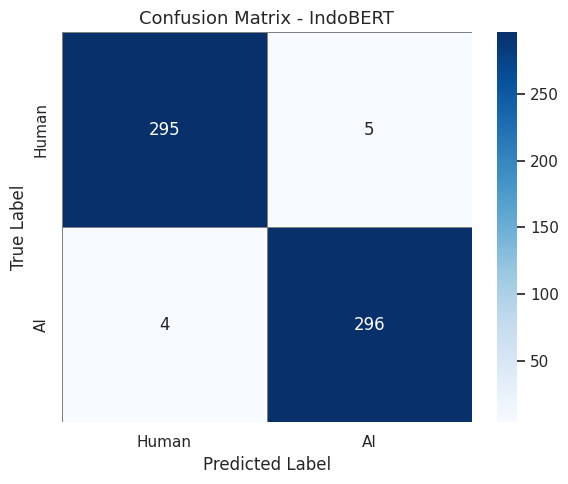


Classification Report:
              precision    recall  f1-score   support

       Human       0.99      0.98      0.98       300
          AI       0.98      0.99      0.99       300

    accuracy                           0.98       600
   macro avg       0.99      0.98      0.98       600
weighted avg       0.99      0.98      0.98       600

Saved prediction with confidence: /content/drive/MyDrive/Deep-Learning/AOL_II/Results3/HumanVsAI_Text-Classification/model_artifacts/IndoBERT/IndoBERT_predictions_with_confidence.csv


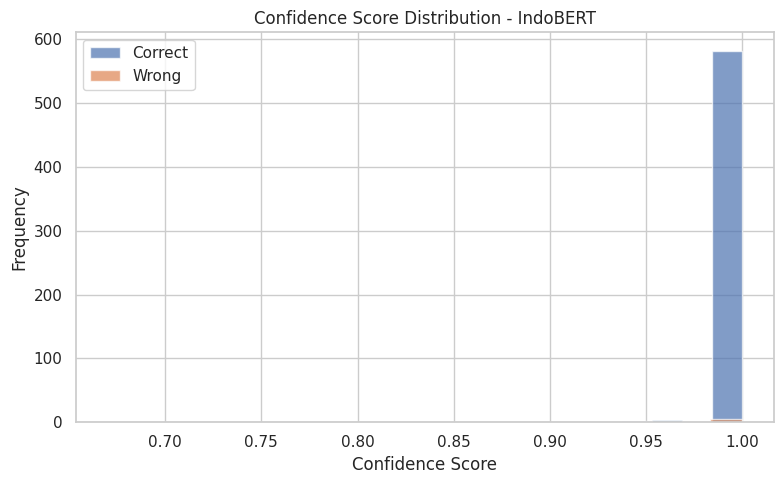

Saved PT: /content/drive/MyDrive/Deep-Learning/AOL_II/Results3/HumanVsAI_Text-Classification/model_artifacts/IndoBERT/IndoBERT.pt
Saved tokenizer: /content/drive/MyDrive/Deep-Learning/AOL_II/Results3/HumanVsAI_Text-Classification/model_artifacts/IndoBERT/tokenizer


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved HF encoder: /content/drive/MyDrive/Deep-Learning/AOL_II/Results3/HumanVsAI_Text-Classification/model_artifacts/IndoBERT/encoder_huggingface
Saved H5: /content/drive/MyDrive/Deep-Learning/AOL_II/Results3/HumanVsAI_Text-Classification/model_artifacts/IndoBERT/IndoBERT.h5
ONNX export failed: No module named 'onnxscript'


In [ ]:
# TRAIN INDOBERT

indobert_model, indobert_tokenizer, indobert_metrics, indobert_pred_df = train_transformer_model(
    model_name=INDOBERT_MODEL_NAME,
    model_short_name="IndoBERT"
)

Training XLM_RoBERTa: xlm-roberta-base
Transformer batch size: 16
Transformer epochs: 3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Epoch 1/3
Train Loss: 0.3436

Evaluation Metrics - XLM_RoBERTa Train
--------------------------------------------------
accuracy: 0.8574
precision: 0.8447
recall: 0.8755
f1_score: 0.8599
Val Loss: 0.2218

Evaluation Metrics - XLM_RoBERTa Validation
--------------------------------------------------
accuracy: 0.9583
precision: 0.9791
recall: 0.9367
f1_score: 0.9574
roc_auc: 0.9742

Epoch 2/3
Train Loss: 0.1475

Evaluation Metrics - XLM_RoBERTa Train
--------------------------------------------------
accuracy: 0.9668
precision: 0.9880
recall: 0.9449
f1_score: 0.9660
Val Loss: 0.1317

Evaluation Metrics - XLM_RoBERTa Validation
--------------------------------------------------
accuracy: 0.9650
precision: 0.9697
recall: 0.9600
f1_score: 0.9648
roc_auc: 0.9951

Epoch 3/3
Train Loss: 0.0551

Evaluation Metrics - XLM_RoBERTa Train
--------------------------------------------------
accuracy: 0.9868
precision: 0.9956
recall: 0.9778
f1_score: 0.9866
Val Loss: 0.1155

Evaluation Metrics - XLM_R

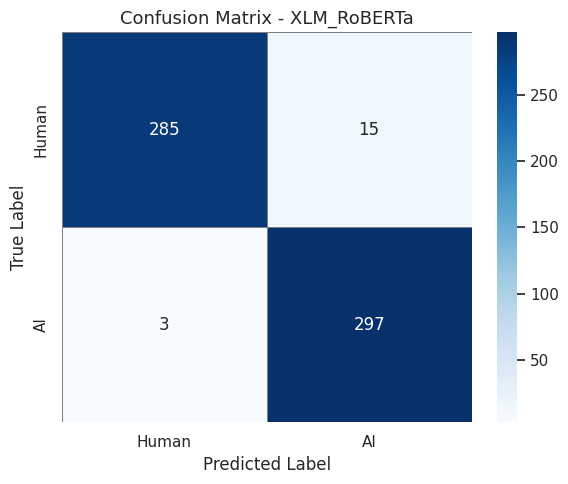


Classification Report:
              precision    recall  f1-score   support

       Human       0.99      0.95      0.97       300
          AI       0.95      0.99      0.97       300

    accuracy                           0.97       600
   macro avg       0.97      0.97      0.97       600
weighted avg       0.97      0.97      0.97       600

Saved prediction with confidence: /content/drive/MyDrive/Deep-Learning/AOL_II/Results3/HumanVsAI_Text-Classification/model_artifacts/XLM_RoBERTa/XLM_RoBERTa_predictions_with_confidence.csv


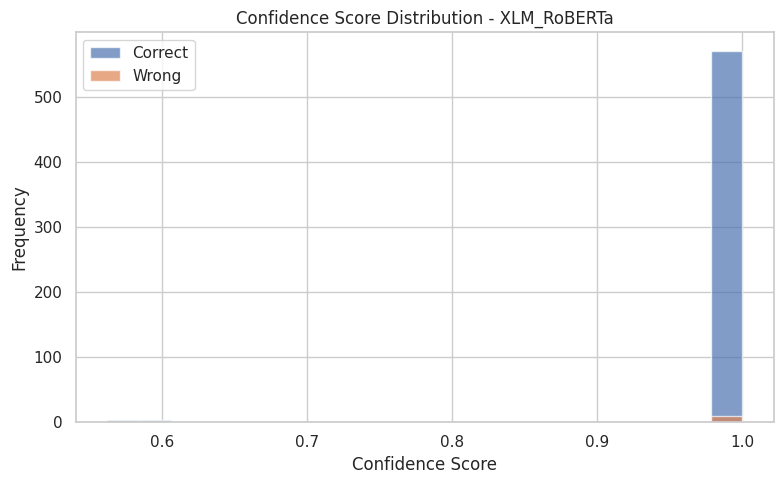

Saved PT: /content/drive/MyDrive/Deep-Learning/AOL_II/Results3/HumanVsAI_Text-Classification/model_artifacts/XLM_RoBERTa/XLM_RoBERTa.pt
Saved tokenizer: /content/drive/MyDrive/Deep-Learning/AOL_II/Results3/HumanVsAI_Text-Classification/model_artifacts/XLM_RoBERTa/tokenizer


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved HF encoder: /content/drive/MyDrive/Deep-Learning/AOL_II/Results3/HumanVsAI_Text-Classification/model_artifacts/XLM_RoBERTa/encoder_huggingface
Saved H5: /content/drive/MyDrive/Deep-Learning/AOL_II/Results3/HumanVsAI_Text-Classification/model_artifacts/XLM_RoBERTa/XLM_RoBERTa.h5
ONNX export failed: No module named 'onnxscript'


In [ ]:
# TRAIN XLM-ROBERTA

xlmr_model, xlmr_tokenizer, xlmr_metrics, xlmr_pred_df = train_transformer_model(
    model_name=XLMR_MODEL_NAME,
    model_short_name="XLM_RoBERTa"
)

## BiLSTM

In [ ]:
# DOWNLOAD FASTTEXT INDONESIAN WORD VECTOR

EMBEDDING_DIR = Path("/content/embeddings")
EMBEDDING_DIR.mkdir(parents=True, exist_ok=True)

FASTTEXT_PATH = EMBEDDING_DIR / "cc.id.300.vec.gz"
PRETRAINED_EMBEDDING_PATH = str(FASTTEXT_PATH)

if not FASTTEXT_PATH.exists():
    print("FastText Indonesian embedding belum ada di session. Mulai download...")

    !wget -c https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.id.300.vec.gz \
        -O /content/embeddings/cc.id.300.vec.gz

    print("Download selesai:", FASTTEXT_PATH)
else:
    print("FastText embedding sudah tersedia di session:", FASTTEXT_PATH)

print("PRETRAINED_EMBEDDING_PATH:", PRETRAINED_EMBEDDING_PATH)

FastText Indonesian embedding belum ada di session. Mulai download...
--2026-05-06 22:29:54--  https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.id.300.vec.gz
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 65.9.168.81, 65.9.168.52, 65.9.168.4, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|65.9.168.81|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1227018698 (1.1G) [binary/octet-stream]
Saving to: ‘/content/embeddings/cc.id.300.vec.gz’

/content/embeddings 100%[===================>]   1.14G   505MB/s    in 2.3s    

2026-05-06 22:29:57 (505 MB/s) - ‘/content/embeddings/cc.id.300.vec.gz’ saved [1227018698/1227018698]

Download selesai: /content/embeddings/cc.id.300.vec.gz
PRETRAINED_EMBEDDING_PATH: /content/embeddings/cc.id.300.vec.gz


In [ ]:
embedding_matrix, EMBED_DIM, embedding_summary = load_pretrained_embedding_matrix(
    embedding_path=PRETRAINED_EMBEDDING_PATH,
    vocab=vocab
)

print("Final EMBED_DIM:", EMBED_DIM)

Loading pretrained embedding:
/content/embeddings/cc.id.300.vec.gz
Detected header. Embedding dim: 300
Processed 500,000 embedding lines | matched: 8,341
Processed 1,000,000 embedding lines | matched: 8,544
Processed 1,500,000 embedding lines | matched: 8,629
Processed 2,000,000 embedding lines | matched: 8,655

FastText embedding summary
--------------------------------------------------
Embedding dim : 300
Vocab size    : 9068
Matched words : 8655
Coverage      : 0.9544552271724747
Final EMBED_DIM: 300


In [ ]:
# BILSTM PREPROCESSING and VOCABULARY

def clean_text_for_bilstm(text):
    text = str(text).lower()

    # Hapus URL
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Hapus mention dan hashtag
    text = re.sub(r"@\w+|#\w+", " ", text)

    # Hapus karakter selain huruf, angka, dan spasi
    text = re.sub(r"[^a-zA-ZÀ-ÿ0-9\s]", " ", text)

    # Normalisasi spasi
    text = re.sub(r"\s+", " ", text).strip()

    return text


def tokenize_for_bilstm(text):
    return clean_text_for_bilstm(text).split()


# Vocabulary hanya dari training set
train_tokens = train_df[TEXT_COL].apply(tokenize_for_bilstm).tolist()

counter = Counter()

for tokens in train_tokens:
    counter.update(tokens)

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

vocab = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1
}

for word, freq in counter.most_common(MAX_VOCAB_SIZE - 2):
    if freq >= MIN_FREQ:
        vocab[word] = len(vocab)

idx_to_word = {idx: word for word, idx in vocab.items()}

print("BiLSTM vocab size:", len(vocab))
print("Contoh vocab:", list(vocab.items())[:20])

with open(MODEL_ARTIFACT_DIR / "bilstm_vocab_from_train_only.json", "w") as f:
    json.dump(vocab, f, indent=4)

BiLSTM vocab size: 9068
Contoh vocab: [('<PAD>', 0), ('<UNK>', 1), ('yang', 2), ('itu', 3), ('di', 4), ('dan', 5), ('saya', 6), ('ini', 7), ('kita', 8), ('ada', 9), ('tidak', 10), ('dari', 11), ('untuk', 12), ('dengan', 13), ('jadi', 14), ('karena', 15), ('bisa', 16), ('ya', 17), ('ke', 18), ('kalau', 19)]


In [ ]:
# LOAD FASTTEXT EMBEDDING MATRIX

def open_embedding_file(path):
    path = str(path)

    if path.endswith(".gz"):
        return gzip.open(path, "rt", encoding="utf-8", errors="ignore")
    else:
        return open(path, "r", encoding="utf-8", errors="ignore")


def load_pretrained_embedding_matrix(
    embedding_path,
    vocab,
    random_scale=0.05
):
    """
    Membuat embedding matrix sesuai vocabulary BiLSTM.

    embedding_path:
        path ke file FastText .vec.gz / .vec / .txt

    vocab:
        vocabulary dari train set

    Output:
        embedding_matrix: numpy array [vocab_size, embedding_dim]
        embed_dim
        summary
    """

    embedding_path = Path(embedding_path)

    if not embedding_path.exists():
        raise FileNotFoundError(f"File embedding tidak ditemukan: {embedding_path}")

    print("Loading pretrained embedding:")
    print(embedding_path)

    vocab_set = set(vocab.keys())
    vectors = {}
    embed_dim = None

    with open_embedding_file(embedding_path) as f:
        first_line = f.readline().strip().split()

        # FastText .vec biasanya punya header:
        # jumlah_kata dimensi
        has_header = (
            len(first_line) == 2
            and first_line[0].isdigit()
            and first_line[1].isdigit()
        )

        if has_header:
            embed_dim = int(first_line[1])
            print("Detected header. Embedding dim:", embed_dim)
        else:
            # Kalau tidak ada header, proses baris pertama sebagai vector
            if len(first_line) > 2:
                word = first_line[0]
                values = first_line[1:]

                try:
                    vector = np.array(values, dtype=np.float32)
                    embed_dim = len(vector)

                    if word in vocab_set:
                        vectors[word] = vector
                except ValueError:
                    pass

        line_count = 0

        for line in f:
            line_count += 1

            if line_count % 500000 == 0:
                print(f"Processed {line_count:,} embedding lines | matched: {len(vectors):,}")

            parts = line.rstrip().split(" ")

            if len(parts) <= 2:
                continue

            word = parts[0]

            if word not in vocab_set:
                continue

            try:
                vector = np.array(parts[1:], dtype=np.float32)
            except ValueError:
                continue

            if embed_dim is None:
                embed_dim = len(vector)

            if len(vector) != embed_dim:
                continue

            vectors[word] = vector

    if embed_dim is None:
        raise ValueError("Embedding dimension gagal dideteksi.")

    embedding_matrix = np.random.uniform(
        -random_scale,
        random_scale,
        size=(len(vocab), embed_dim)
    ).astype(np.float32)

    # PAD token dibuat nol
    embedding_matrix[vocab[PAD_TOKEN]] = np.zeros(embed_dim, dtype=np.float32)

    matched_words = 0

    for word, idx in vocab.items():
        if word in vectors:
            embedding_matrix[idx] = vectors[word]
            matched_words += 1

    coverage = matched_words / len(vocab)

    summary = {
        "embedding_type": "FastText Indonesian pretrained word vectors",
        "embedding_path": str(embedding_path),
        "embedding_dim": int(embed_dim),
        "vocab_size": int(len(vocab)),
        "matched_words": int(matched_words),
        "coverage": float(coverage),
        "freeze_embedding": bool(FREEZE_EMBEDDING)
    }

    print("\nFastText embedding summary")
    print("-" * 50)
    print("Embedding dim :", embed_dim)
    print("Vocab size    :", len(vocab))
    print("Matched words :", matched_words)
    print("Coverage      :", coverage)

    with open(MODEL_ARTIFACT_DIR / "bilstm_fasttext_embedding_summary.json", "w") as f:
        json.dump(summary, f, indent=4)

    return embedding_matrix, embed_dim, summary


embedding_matrix, EMBED_DIM, embedding_summary = load_pretrained_embedding_matrix(
    embedding_path=PRETRAINED_EMBEDDING_PATH,
    vocab=vocab
)

print("Final EMBED_DIM:", EMBED_DIM)

Loading pretrained embedding:
/content/embeddings/cc.id.300.vec.gz
Detected header. Embedding dim: 300
Processed 500,000 embedding lines | matched: 8,341
Processed 1,000,000 embedding lines | matched: 8,544
Processed 1,500,000 embedding lines | matched: 8,629
Processed 2,000,000 embedding lines | matched: 8,655

FastText embedding summary
--------------------------------------------------
Embedding dim : 300
Vocab size    : 9068
Matched words : 8655
Coverage      : 0.9544552271724747
Final EMBED_DIM: 300


In [ ]:
# BILSTM DATASET

def encode_text_bilstm(text, vocab, max_len):
    tokens = tokenize_for_bilstm(text)

    ids = [vocab.get(token, vocab[UNK_TOKEN]) for token in tokens]

    if len(ids) > max_len:
        ids = ids[:max_len]

    while len(ids) < max_len:
        ids.append(vocab[PAD_TOKEN])

    return ids


class BiLSTMDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = texts.astype(str).tolist()
        self.labels = labels.astype(int).tolist()
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = encode_text_bilstm(
            self.texts[idx],
            self.vocab,
            self.max_len
        )

        return {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [ ]:
# BILSTM CLASSIFIER WITH FASTTEXT WORD EMBEDDING

class BiLSTMClassifier(nn.Module):
    def __init__(
        self,
        embedding_matrix,
        hidden_dim,
        num_layers,
        num_labels,
        pad_idx,
        dropout=0.5,
        freeze_embedding=False
    ):
        super().__init__()

        embedding_tensor = torch.tensor(embedding_matrix, dtype=torch.float)

        self.embedding = nn.Embedding.from_pretrained(
            embeddings=embedding_tensor,
            freeze=freeze_embedding,
            padding_idx=pad_idx
        )

        embed_dim = embedding_matrix.shape[1]

        self.bilstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)

        outputs, (hidden, cell) = self.bilstm(embedded)

        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]

        final_hidden = torch.cat((forward_hidden, backward_hidden), dim=1)

        logits = self.classifier(self.dropout(final_hidden))

        return logits

    def extract_features(self, input_ids):
        self.eval()

        with torch.no_grad():
            embedded = self.embedding(input_ids)
            outputs, (hidden, cell) = self.bilstm(embedded)

            forward_hidden = hidden[-2]
            backward_hidden = hidden[-1]

            final_hidden = torch.cat((forward_hidden, backward_hidden), dim=1)

        return final_hidden

In [ ]:
# BILSTM TRAINING AND EVALUATION FUNCTIONS

def train_one_epoch_bilstm(model, dataloader, optimizer, criterion):
    model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in dataloader:
        input_ids = batch["input_ids"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        optimizer.zero_grad()

        logits = model(input_ids)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader)

    metrics = compute_metrics(
        y_true=np.array(all_labels),
        y_pred=np.array(all_preds),
        y_prob_ai=None
    )

    return avg_loss, metrics


def evaluate_bilstm(model, dataloader, criterion):
    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs_ai = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            logits = model(input_ids)
            loss = criterion(logits, labels)

            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)
            probs_ai = probs[:, 1]

            preds = torch.argmax(logits, dim=1)

            all_probs_ai.extend(probs_ai.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader)

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob_ai = np.array(all_probs_ai)

    metrics = compute_metrics(
        y_true=y_true,
        y_pred=y_pred,
        y_prob_ai=y_prob_ai
    )

    return avg_loss, metrics, y_true, y_pred, y_prob_ai

In [ ]:
# # BILSTM TRAINING FUNCTIONS

# def train_one_epoch_bilstm(model, dataloader, optimizer, criterion):
#     model.train()

#     total_loss = 0
#     all_preds = []
#     all_labels = []

#     for batch in dataloader:
#         input_ids = batch["input_ids"].to(DEVICE)
#         labels = batch["labels"].to(DEVICE)

#         optimizer.zero_grad()

#         logits = model(input_ids)
#         loss = criterion(logits, labels)

#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

#         optimizer.step()

#         total_loss += loss.item()

#         preds = torch.argmax(logits, dim=1)

#         all_preds.extend(preds.detach().cpu().numpy())
#         all_labels.extend(labels.detach().cpu().numpy())

#     avg_loss = total_loss / len(dataloader)

#     metrics = compute_metrics(
#         y_true=np.array(all_labels),
#         y_pred=np.array(all_preds),
#         y_prob_ai=None
#     )

#     return avg_loss, metrics


# def evaluate_bilstm(model, dataloader, criterion):
#     model.eval()

#     total_loss = 0
#     all_preds = []
#     all_labels = []
#     all_probs_ai = []

#     with torch.no_grad():
#         for batch in dataloader:
#             input_ids = batch["input_ids"].to(DEVICE)
#             labels = batch["labels"].to(DEVICE)

#             logits = model(input_ids)
#             loss = criterion(logits, labels)

#             total_loss += loss.item()

#             probs = torch.softmax(logits, dim=1)
#             probs_ai = probs[:, 1]

#             preds = torch.argmax(logits, dim=1)

#             all_probs_ai.extend(probs_ai.detach().cpu().numpy())
#             all_preds.extend(preds.detach().cpu().numpy())
#             all_labels.extend(labels.detach().cpu().numpy())

#     avg_loss = total_loss / len(dataloader)

#     y_true = np.array(all_labels)
#     y_pred = np.array(all_preds)
#     y_prob_ai = np.array(all_probs_ai)

#     metrics = compute_metrics(
#         y_true=y_true,
#         y_pred=y_pred,
#         y_prob_ai=y_prob_ai
#     )

#     return avg_loss, metrics, y_true, y_pred, y_prob_ai

In [ ]:
# SAVE BILSTM ARTIFACTS

def save_bilstm_artifacts(model, model_dir, vocab, embedding_summary):
    model.eval()
    model_dir.mkdir(parents=True, exist_ok=True)

    # Save .pt
    pt_path = model_dir / "BiLSTM_FastText.pt"

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "vocab": vocab,
            "max_len": BILSTM_MAX_LEN,
            "embed_dim": EMBED_DIM,
            "hidden_dim": HIDDEN_DIM,
            "num_layers": NUM_LAYERS,
            "num_labels": NUM_LABELS,
            "pad_token": PAD_TOKEN,
            "unk_token": UNK_TOKEN,
            "freeze_embedding": FREEZE_EMBEDDING,
            "embedding_summary": embedding_summary
        },
        pt_path
    )

    print("Saved PT:", pt_path)

    # Save vocab
    vocab_path = model_dir / "vocab.json"

    with open(vocab_path, "w") as f:
        json.dump(vocab, f, indent=4)

    print("Saved vocab:", vocab_path)

    # Save embedding summary
    embedding_summary_path = model_dir / "embedding_summary.json"

    with open(embedding_summary_path, "w") as f:
        json.dump(embedding_summary, f, indent=4)

    print("Saved embedding summary:", embedding_summary_path)

    # Save H5
    h5_path = model_dir / "BiLSTM_FastText.h5"

    save_state_dict_to_h5(model, h5_path)

    print("Saved H5:", h5_path)

    # Save ONNX
    onnx_path = model_dir / "BiLSTM_FastText.onnx"

    dummy_input_ids = torch.randint(
        low=0,
        high=len(vocab),
        size=(1, BILSTM_MAX_LEN),
        dtype=torch.long
    ).to(DEVICE)

    try:
        torch.onnx.export(
            model,
            dummy_input_ids,
            onnx_path,
            input_names=["input_ids"],
            output_names=["logits"],
            dynamic_axes={
                "input_ids": {0: "batch_size", 1: "sequence_length"},
                "logits": {0: "batch_size"}
            },
            opset_version=14
        )

        print("Saved ONNX:", onnx_path)

    except Exception as e:
        print("ONNX export failed:", str(e))

        with open(model_dir / "onnx_export_error.txt", "w") as f:
            f.write(str(e))

Training BiLSTM + FastText
Max epochs: 15
Batch size: 32
Learning rate: 0.0002
Weight decay: 0.05
Hidden dim: 64
Embedding dim: 300
Dropout: 0.5
Freeze embedding: False
Early stopping patience: 3

Epoch 1/15
Train Loss: 0.6914

Evaluation Metrics - BiLSTM + FastText Train
--------------------------------------------------
accuracy: 0.5147
precision: 0.5202
recall: 0.3691
f1_score: 0.4318
Val Loss: 0.6882

Evaluation Metrics - BiLSTM + FastText Validation
--------------------------------------------------
accuracy: 0.5017
precision: 0.6667
recall: 0.0067
f1_score: 0.0132
roc_auc: 0.6548
Validation F1 improved to 0.0132. Best model updated.

Epoch 2/15
Train Loss: 0.6732

Evaluation Metrics - BiLSTM + FastText Train
--------------------------------------------------
accuracy: 0.6151
precision: 0.6801
recall: 0.4335
f1_score: 0.5295
Val Loss: 0.6185

Evaluation Metrics - BiLSTM + FastText Validation
--------------------------------------------------
accuracy: 0.6667
precision: 0.6603
reca

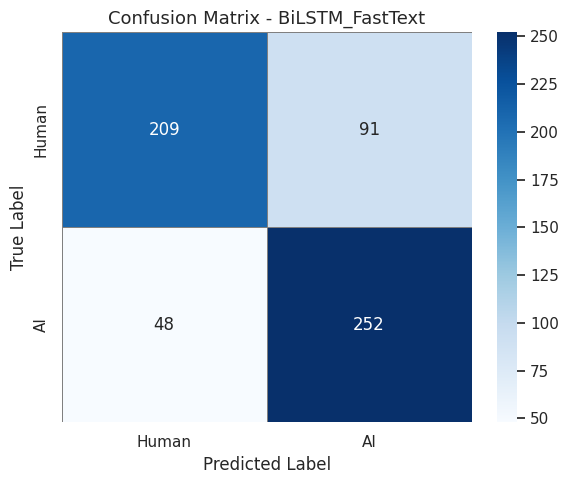


Classification Report:
              precision    recall  f1-score   support

       Human       0.81      0.70      0.75       300
          AI       0.73      0.84      0.78       300

    accuracy                           0.77       600
   macro avg       0.77      0.77      0.77       600
weighted avg       0.77      0.77      0.77       600

Saved prediction with confidence: /content/drive/MyDrive/Deep-Learning/AOL_II/Results3/HumanVsAI_Text-Classification/model_artifacts/BiLSTM_FastText/BiLSTM_FastText_predictions_with_confidence.csv


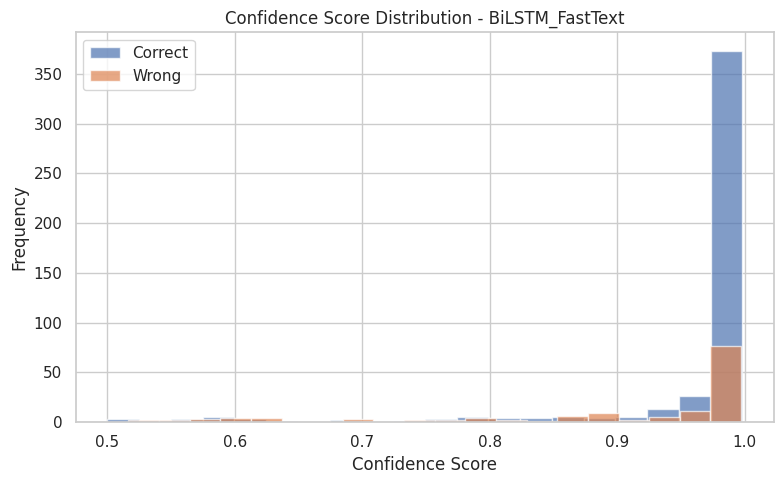

Saved PT: /content/drive/MyDrive/Deep-Learning/AOL_II/Results3/HumanVsAI_Text-Classification/model_artifacts/BiLSTM_FastText/BiLSTM_FastText.pt
Saved vocab: /content/drive/MyDrive/Deep-Learning/AOL_II/Results3/HumanVsAI_Text-Classification/model_artifacts/BiLSTM_FastText/vocab.json
Saved embedding summary: /content/drive/MyDrive/Deep-Learning/AOL_II/Results3/HumanVsAI_Text-Classification/model_artifacts/BiLSTM_FastText/embedding_summary.json
Saved H5: /content/drive/MyDrive/Deep-Learning/AOL_II/Results3/HumanVsAI_Text-Classification/model_artifacts/BiLSTM_FastText/BiLSTM_FastText.h5
ONNX export failed: No module named 'onnxscript'


In [ ]:
# TRAIN BILSTM WITH FASTTEXT + EARLY STOPPING

def train_bilstm_model():
    print("=" * 80)
    print("Training BiLSTM + FastText")
    print("Max epochs:", BILSTM_EPOCHS)
    print("Batch size:", BILSTM_BATCH_SIZE)
    print("Learning rate:", BILSTM_LR)
    print("Weight decay:", BILSTM_WEIGHT_DECAY)
    print("Hidden dim:", HIDDEN_DIM)
    print("Embedding dim:", EMBED_DIM)
    print("Dropout:", DROPOUT)
    print("Freeze embedding:", FREEZE_EMBEDDING)
    print("Early stopping patience:", EARLY_STOPPING_PATIENCE_BILSTM)
    print("=" * 80)

    model_dir = MODEL_ARTIFACT_DIR / "BiLSTM_FastText"
    model_dir.mkdir(parents=True, exist_ok=True)

    train_dataset = BiLSTMDataset(
        train_df[TEXT_COL],
        train_df[LABEL_COL],
        vocab,
        BILSTM_MAX_LEN
    )

    val_dataset = BiLSTMDataset(
        val_df[TEXT_COL],
        val_df[LABEL_COL],
        vocab,
        BILSTM_MAX_LEN
    )

    test_dataset = BiLSTMDataset(
        test_df[TEXT_COL],
        test_df[LABEL_COL],
        vocab,
        BILSTM_MAX_LEN
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BILSTM_BATCH_SIZE,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BILSTM_BATCH_SIZE,
        shuffle=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BILSTM_BATCH_SIZE,
        shuffle=False
    )

    model = BiLSTMClassifier(
        embedding_matrix=embedding_matrix,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        num_labels=NUM_LABELS,
        pad_idx=vocab[PAD_TOKEN],
        dropout=DROPOUT,
        freeze_embedding=FREEZE_EMBEDDING
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=BILSTM_LR,
        weight_decay=BILSTM_WEIGHT_DECAY
    )

    best_val_f1 = -1
    best_state = None
    epochs_without_improvement = 0

    history = []

    for epoch in range(BILSTM_EPOCHS):
        print(f"\nEpoch {epoch + 1}/{BILSTM_EPOCHS}")

        train_loss, train_metrics = train_one_epoch_bilstm(
            model,
            train_loader,
            optimizer,
            criterion
        )

        val_loss, val_metrics, _, _, _ = evaluate_bilstm(
            model,
            val_loader,
            criterion
        )

        print(f"Train Loss: {train_loss:.4f}")
        print_metrics("BiLSTM + FastText Train", train_metrics)

        print(f"Val Loss: {val_loss:.4f}")
        print_metrics("BiLSTM + FastText Validation", val_metrics)

        epoch_log = {
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()}
        }

        history.append(epoch_log)

        current_val_f1 = val_metrics["f1_score"]

        if current_val_f1 > best_val_f1 + MIN_DELTA:
            best_val_f1 = current_val_f1
            epochs_without_improvement = 0

            best_state = {
                "model_state_dict": copy.deepcopy(model.state_dict()),
                "epoch": epoch + 1,
                "best_val_f1": best_val_f1
            }

            print(f"Validation F1 improved to {best_val_f1:.4f}. Best model updated.")

        else:
            epochs_without_improvement += 1

            print(
                f"No improvement. Patience: "
                f"{epochs_without_improvement}/{EARLY_STOPPING_PATIENCE_BILSTM}"
            )

            if epochs_without_improvement >= EARLY_STOPPING_PATIENCE_BILSTM:
                print("Early stopping triggered for BiLSTM + FastText.")
                break

    if best_state is None:
        raise RuntimeError("Best state tidak tersimpan. Cek training loop.")

    model.load_state_dict(best_state["model_state_dict"])

    # Save best model info
    with open(model_dir / "best_model_info.json", "w") as f:
        json.dump(
            {
                "model": "BiLSTM + FastText",
                "best_epoch": best_state["epoch"],
                "best_val_f1": best_state["best_val_f1"],
                "max_epochs": BILSTM_EPOCHS,
                "early_stopping_patience": EARLY_STOPPING_PATIENCE_BILSTM,
                "batch_size": BILSTM_BATCH_SIZE,
                "learning_rate": BILSTM_LR,
                "weight_decay": BILSTM_WEIGHT_DECAY,
                "max_len": BILSTM_MAX_LEN,
                "vocab_size": len(vocab),
                "embedding_dim": EMBED_DIM,
                "hidden_dim": HIDDEN_DIM,
                "dropout": DROPOUT,
                "freeze_embedding": FREEZE_EMBEDDING,
                "embedding_summary": embedding_summary
            },
            f,
            indent=4
        )

    # Save training history
    pd.DataFrame(history).to_csv(model_dir / "training_history.csv", index=False)

    # Final evaluation on test set
    test_loss, test_metrics, y_true, y_pred, y_prob_ai = evaluate_bilstm(
        model,
        test_loader,
        criterion
    )

    print("\n" + "=" * 80)
    print("TEST RESULT - BiLSTM + FastText")
    print("=" * 80)
    print(f"Test Loss: {test_loss:.4f}")

    test_metrics, pred_df = run_full_evaluation(
        model_name="BiLSTM_FastText",
        texts=test_df[TEXT_COL].values,
        y_true=y_true,
        y_pred=y_pred,
        y_prob_ai=y_prob_ai,
        model_output_dir=model_dir
    )

    save_bilstm_artifacts(
        model=model,
        model_dir=model_dir,
        vocab=vocab,
        embedding_summary=embedding_summary
    )

    return model, test_metrics, pred_df


bilstm_model, bilstm_metrics, bilstm_pred_df = train_bilstm_model()

## Comparison

In [ ]:
# COMPARE MODEL PERFORMANCE

comparison_df = pd.DataFrame([
    {"model": "IndoBERT", **indobert_metrics},
    {"model": "XLM-RoBERTa", **xlmr_metrics},
    {"model": "BiLSTM + FastText", **bilstm_metrics}
])

comparison_df.to_csv(COMPARISON_DIR / "model_comparison_metrics.csv", index=False)

comparison_df

,model,accuracy,precision,recall,f1_score,roc_auc
0,IndoBERT,0.985000,0.983389,0.986667,0.985025,0.999422
1,XLM-RoBERTa,0.970000,0.951923,0.990000,0.970588,0.995361
2,BiLSTM + FastText,0.768333,0.734694,0.840000,0.783826,0.870700


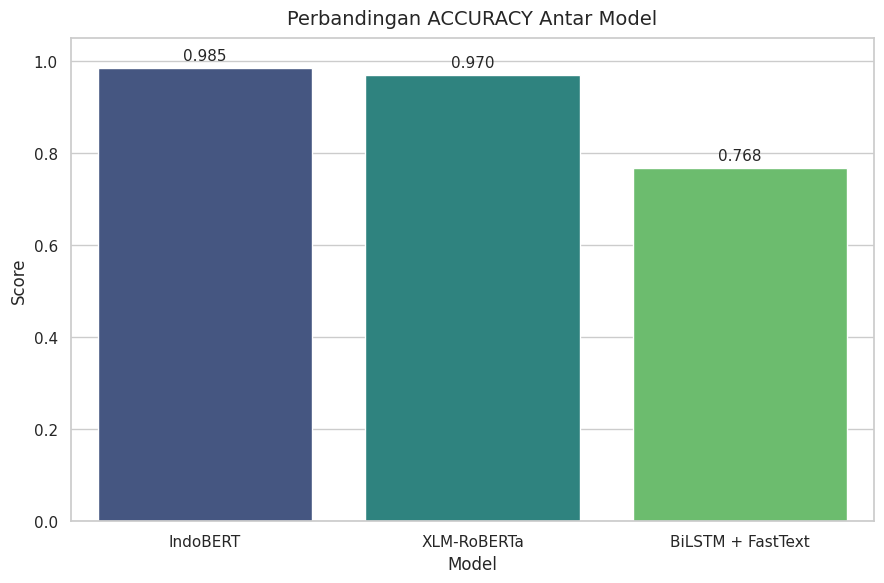

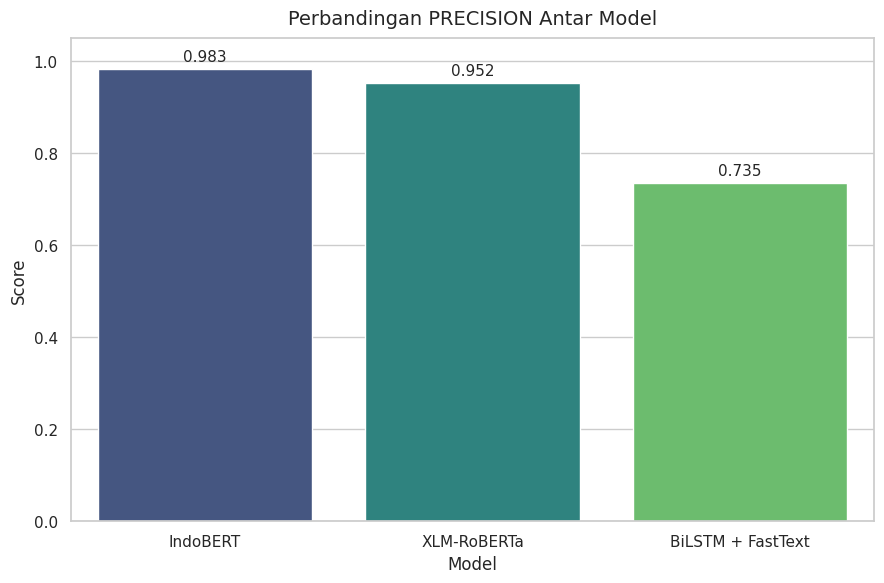

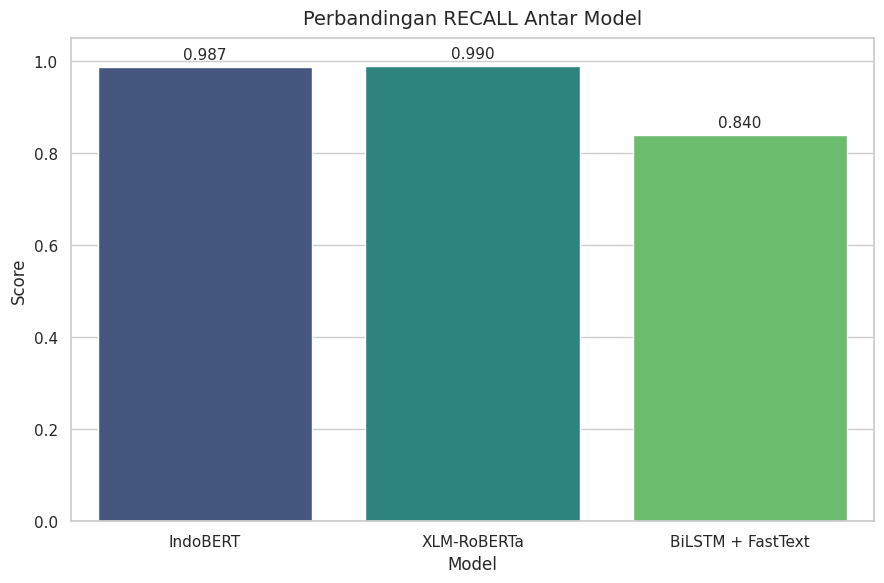

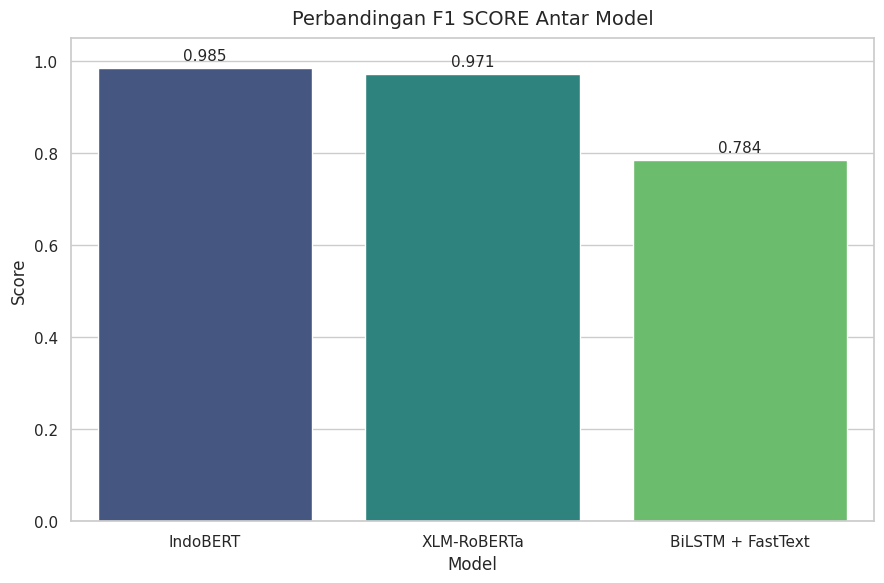

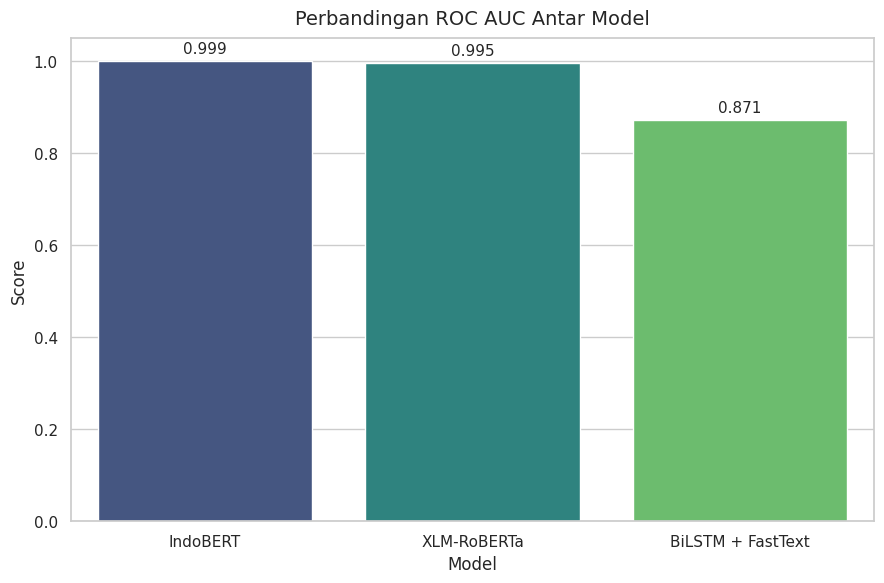

In [ ]:
# BAR CHART COMPARISON

sns.set_theme(style="whitegrid")
metrics_to_plot = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc"
]

for metric in metrics_to_plot:
    if metric in comparison_df.columns:
        plt.figure(figsize=(9, 6))
        ax = sns.barplot(
            data=comparison_df,
            x="model",
            y=metric,
            hue="model",
            palette="viridis",
            legend=False
        )

        for p in ax.patches:
            ax.annotate(f'{p.get_height():.3f}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center',
                        xytext=(0, 9),
                        textcoords='offset points',
                        fontsize=11)

        plt.title(f"Perbandingan {metric.replace('_', ' ').upper()} Antar Model",
                  fontsize=14, pad=10)
        plt.xlabel("Model", fontsize=12)
        plt.ylabel("Score", fontsize=12)
        plt.ylim(0, 1.05)
        plt.tight_layout()
        plt.savefig(COMPARISON_DIR / f"comparison_{metric}.png", dpi=300)
        plt.show()

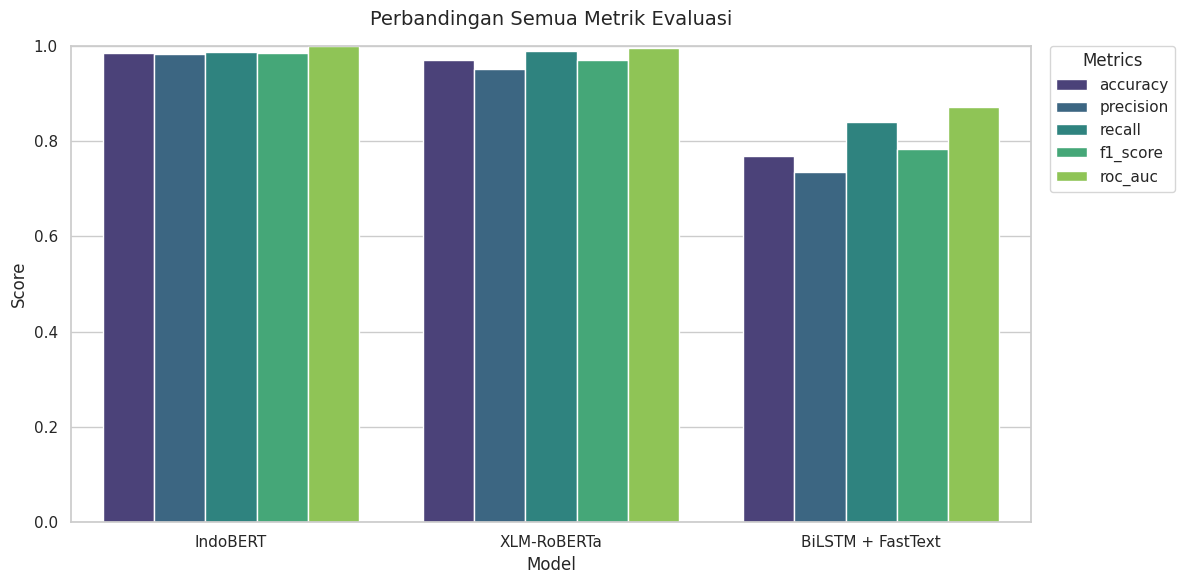

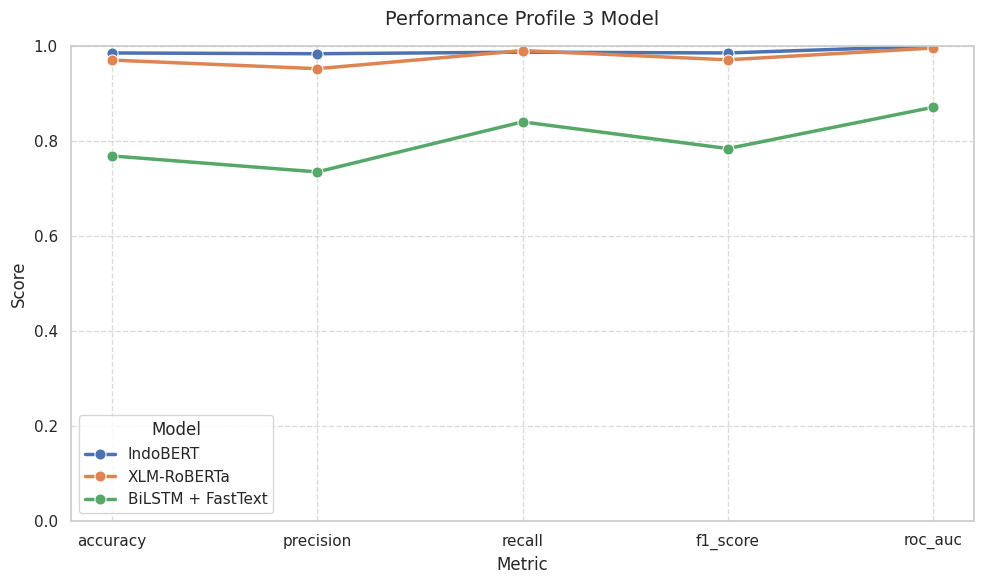

In [ ]:
df_long = comparison_df.melt(id_vars="model", value_vars=metrics_to_plot,
                             var_name="Metric", value_name="Score")

sns.set_theme(style="whitegrid")

# GROUPED BAR CHART ALL METRICS

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_long,
    x="model",
    y="Score",
    hue="Metric",
    palette="viridis"
)

plt.title("Perbandingan Semua Metrik Evaluasi", fontsize=14, pad=15)
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.legend(title="Metrics", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.savefig(COMPARISON_DIR / "comparison_all_metrics_grouped_bar.png", dpi=300)
plt.show()


# LINE CHART COMPARISON

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_long,
    x="Metric",
    y="Score",
    hue="model",
    marker="o",
    markersize=8,
    linewidth=2.5
)

plt.title("Performance Profile 3 Model", fontsize=14, pad=15)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(title="Model")

plt.tight_layout()
plt.savefig(COMPARISON_DIR / "performance_profile_line_chart.png", dpi=300)
plt.show()

In [ ]:
# COMBINE PREDICTIONS WITH CONFIDENCE

all_predictions_df = pd.concat(
    [
        indobert_pred_df,
        xlmr_pred_df,
        bilstm_pred_df
    ],
    ignore_index=True
)

all_predictions_df.to_csv(
    COMPARISON_DIR / "all_models_predictions_with_confidence.csv",
    index=False
)

all_predictions_df.head()

,model,text,true_label,pred_label,prob_human,prob_ai,confidence_score,true_label_name,pred_label_name,is_correct
0,IndoBERT,"semuanya dipilih. Memang begitulah cara kami, ...",1,1,0.000049,0.999951,0.999951,AI,AI,True
1,IndoBERT,Menanggapi kemungkinan Menkeu Bambang Soedibyo...,1,1,0.000006,0.999994,0.999994,AI,AI,True
2,IndoBERT,"sesaat sebelum menerima kwik, gus dur diketahu...",0,0,0.999993,0.000007,0.999993,Human,Human,True
3,IndoBERT,"Kopral Stewart McMillan Jones (27), seorang pr...",1,1,0.000006,0.999994,0.999994,AI,AI,True
4,IndoBERT,"Dalam kesempatan tersebut, Amien Rais juga mel...",1,1,0.000007,0.999993,0.999993,AI,AI,True


In [ ]:
# CONFIDENCE SUMMARY

confidence_summary = all_predictions_df.groupby("model").agg(
    avg_confidence=("confidence_score", "mean"),
    total_samples=("confidence_score", "count"),
    total_correct=("is_correct", "sum")
).reset_index()

confidence_summary["accuracy_from_prediction_file"] = (
    confidence_summary["total_correct"] / confidence_summary["total_samples"]
)

avg_correct = (
    all_predictions_df[all_predictions_df["is_correct"] == True]
    .groupby("model")["confidence_score"]
    .mean()
    .reset_index()
    .rename(columns={"confidence_score": "avg_confidence_correct"})
)

avg_wrong = (
    all_predictions_df[all_predictions_df["is_correct"] == False]
    .groupby("model")["confidence_score"]
    .mean()
    .reset_index()
    .rename(columns={"confidence_score": "avg_confidence_wrong"})
)

confidence_summary = confidence_summary.merge(avg_correct, on="model", how="left")
confidence_summary = confidence_summary.merge(avg_wrong, on="model", how="left")

confidence_summary.to_csv(
    COMPARISON_DIR / "confidence_summary.csv",
    index=False
)

confidence_summary

,model,avg_confidence,total_samples,total_correct,accuracy_from_prediction_file,avg_confidence_correct,avg_confidence_wrong
0,BiLSTM_FastText,0.950330,600,461,0.768333,0.963607,0.906296
1,IndoBERT,0.996994,600,591,0.985000,0.998255,0.914226
2,XLM_RoBERTa,0.990222,600,582,0.970000,0.993478,0.884934


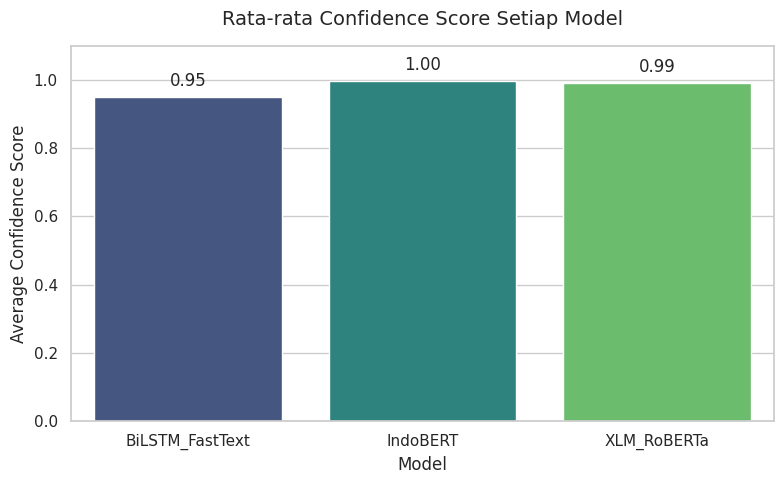

In [ ]:
# AVERAGE CONFIDENCE SCORE BY MODEL
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=confidence_summary,
    x="model",
    y="avg_confidence",
    hue="model",
    legend=False,
    palette="viridis"
)

plt.title("Rata-rata Confidence Score Setiap Model", fontsize=14, pad=15)
plt.xlabel("Model")
plt.ylabel("Average Confidence Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.savefig(COMPARISON_DIR / "average_confidence_score_by_model.png", dpi=300)
plt.show()

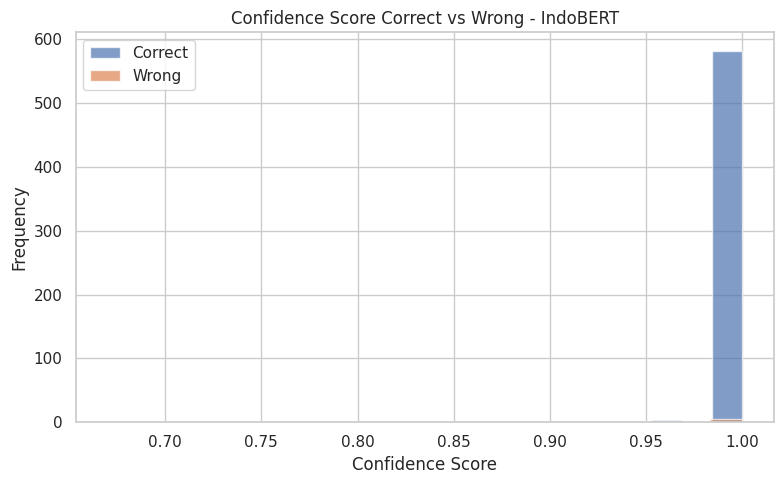

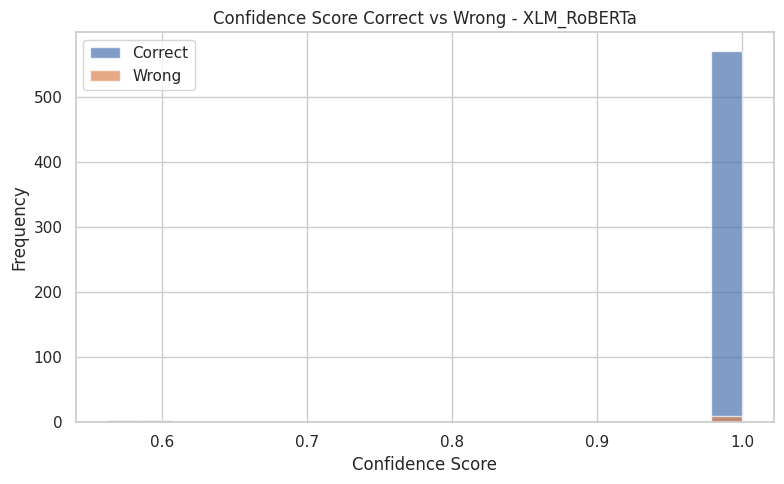

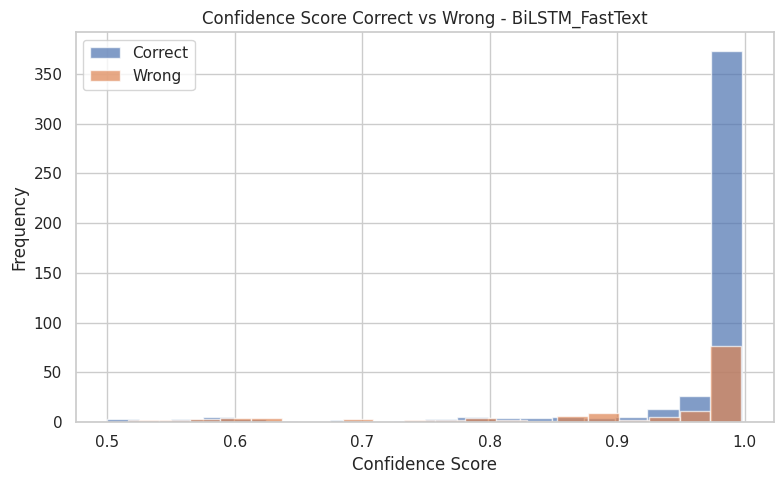

In [ ]:
# CONFIDENCE CORRECT VS WRONG BY MODEL

models = all_predictions_df["model"].unique()
for model in models:
    subset = all_predictions_df[all_predictions_df["model"] == model]

    correct_conf = subset[subset["is_correct"] == True]["confidence_score"]
    wrong_conf = subset[subset["is_correct"] == False]["confidence_score"]

    plt.figure(figsize=(8, 5))
    plt.hist(correct_conf, bins=20, alpha=0.7, label="Correct")
    plt.hist(wrong_conf, bins=20, alpha=0.7, label="Wrong")
    plt.title(f"Confidence Score Correct vs Wrong - {model}")
    plt.xlabel("Confidence Score")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.savefig(COMPARISON_DIR / f"confidence_correct_vs_wrong_{model}.png", dpi=300)
    plt.show()

Feature Representation

In [ ]:
# FEATURE REPRESENTATION EXTRACTION

def extract_transformer_representations(model, tokenizer, sample_df, max_len=TRANSFORMER_MAX_LEN, batch_size=TRANSFORMER_BATCH_SIZE):
    dataset = TransformerTextDataset(
        sample_df[TEXT_COL],
        sample_df[LABEL_COL],
        tokenizer,
        max_len
    )

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    all_features = []
    all_labels = []

    model.eval()

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].cpu().numpy()

            features = model.extract_features(input_ids, attention_mask)

            all_features.append(features.detach().cpu().numpy())
            all_labels.extend(labels)

    return np.vstack(all_features), np.array(all_labels)


def extract_bilstm_representations(model, sample_df, vocab, max_len=BILSTM_MAX_LEN, batch_size=BILSTM_BATCH_SIZE):
    dataset = BiLSTMDataset(
        sample_df[TEXT_COL],
        sample_df[LABEL_COL],
        vocab,
        max_len
    )

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    all_features = []
    all_labels = []

    model.eval()

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            labels = batch["labels"].cpu().numpy()

            features = model.extract_features(input_ids)

            all_features.append(features.detach().cpu().numpy())
            all_labels.extend(labels)

    return np.vstack(all_features), np.array(all_labels)


def plot_2d_representation(features, labels, title, save_path):
    reducer = PCA(n_components=2, random_state=SEED)
    reduced = reducer.fit_transform(features)

    plt.figure(figsize=(7, 6))

    human_idx = labels == 0
    ai_idx = labels == 1

    plt.scatter(
        reduced[human_idx, 0],
        reduced[human_idx, 1],
        label="Human",
        alpha=0.7
    )

    plt.scatter(
        reduced[ai_idx, 0],
        reduced[ai_idx, 1],
        label="AI",
        alpha=0.7
    )

    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

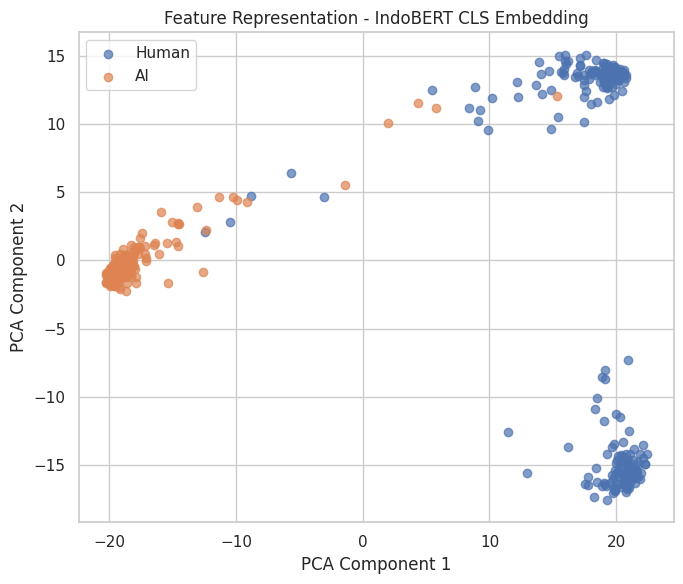

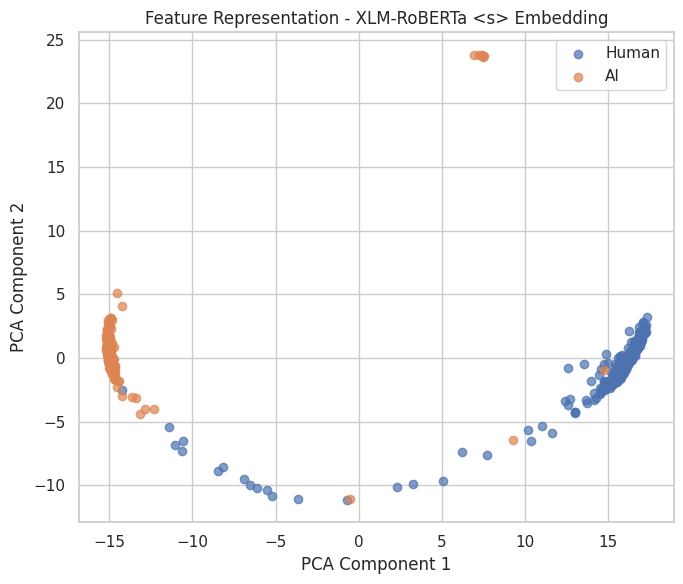

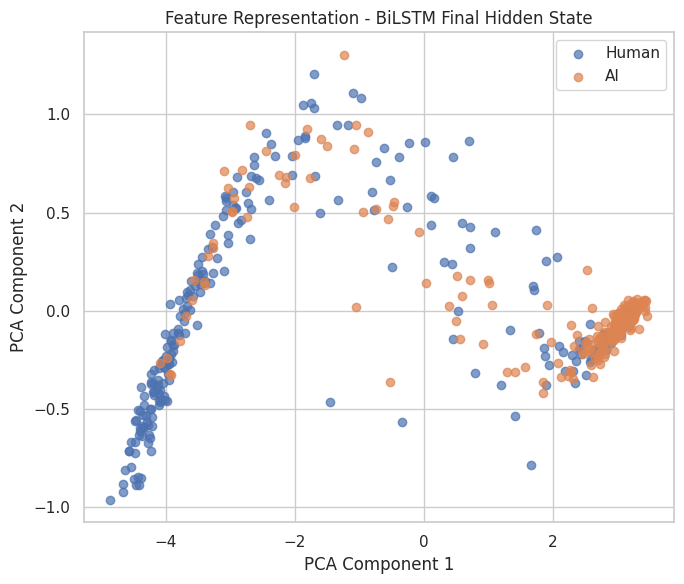

In [ ]:
# FEATURE REPRESENTATION VISUALIZATION

sample_size = min(500, len(test_df))
sample_df = test_df.sample(sample_size, random_state=SEED).reset_index(drop=True)

indobert_features, labels_rep = extract_transformer_representations(
    indobert_model,
    indobert_tokenizer,
    sample_df
)

plot_2d_representation(
    indobert_features,
    labels_rep,
    "Feature Representation - IndoBERT CLS Embedding",
    REPRESENTATION_DIR / "indobert_pca.png"
)

xlmr_features, labels_rep = extract_transformer_representations(
    xlmr_model,
    xlmr_tokenizer,
    sample_df
)

plot_2d_representation(
    xlmr_features,
    labels_rep,
    "Feature Representation - XLM-RoBERTa <s> Embedding",
    REPRESENTATION_DIR / "xlmr_pca.png"
)

bilstm_features, labels_rep = extract_bilstm_representations(
    bilstm_model,
    sample_df,
    vocab
)

plot_2d_representation(
    bilstm_features,
    labels_rep,
    "Feature Representation - BiLSTM Final Hidden State",
    REPRESENTATION_DIR / "bilstm_pca.png"
)

In [ ]:
# SAVE EXPERIMENT SUMMARY

fairness_summary = {
    "same_train_val_test_split_for_all_models": True,
    "stratified_split": GROUP_COL is None,
    "group_split_used": GROUP_COL is not None,
    "group_col": GROUP_COL,
    "exact_leakage_check_done": True,
    "near_duplicate_check_done": True,
    "bilstm_vocab_from_train_only": True,
    "same_metrics_for_all_models": [
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "confusion_matrix",
        "classification_report",
        "confidence_score"
    ],
    "transformer_models": {
        "IndoBERT": INDOBERT_MODEL_NAME,
        "XLM-RoBERTa": XLMR_MODEL_NAME,
        "same_batch_size": TRANSFORMER_BATCH_SIZE,
        "same_epochs": TRANSFORMER_EPOCHS,
        "same_learning_rate": TRANSFORMER_LR,
        "same_max_len": TRANSFORMER_MAX_LEN
    },
    "bilstm_config": {
        "batch_size": BILSTM_BATCH_SIZE,
        "epochs": BILSTM_EPOCHS,
        "learning_rate": BILSTM_LR,
        "max_len": BILSTM_MAX_LEN,
        "embedding_dim": EMBED_DIM,
        "hidden_dim": HIDDEN_DIM,
        "num_layers": NUM_LAYERS,
        "vocab_size": len(vocab)
    },
    "class_weight": {
        "used": class_weights is not None,
        "imbalance_threshold": IMBALANCE_THRESHOLD
    }
}

with open(OUTPUT_ROOT / "fairness_experiment_summary.json", "w") as f:
    json.dump(fairness_summary, f, indent=4)

fairness_summary

{'same_train_val_test_split_for_all_models': True,
 'stratified_split': True,
 'group_split_used': False,
 'group_col': None,
 'exact_leakage_check_done': True,
 'near_duplicate_check_done': True,
 'bilstm_vocab_from_train_only': True,
 'same_metrics_for_all_models': ['accuracy',
  'precision',
  'recall',
  'f1_score',
  'roc_auc',
  'confusion_matrix',
  'classification_report',
  'confidence_score'],
 'transformer_models': {'IndoBERT': 'indobenchmark/indobert-base-p2',
  'XLM-RoBERTa': 'xlm-roberta-base',
  'same_batch_size': 16,
  'same_epochs': 3,
  'same_learning_rate': 2e-05,
  'same_max_len': 192},
 'bilstm_config': {'batch_size': 32,
  'epochs': 15,
  'learning_rate': 0.0002,
  'max_len': 192,
  'embedding_dim': 300,
  'hidden_dim': 64,
  'num_layers': 1,
  'vocab_size': 9068},
 'class_weight': {'used': False, 'imbalance_threshold': 0.1}}

In [ ]:
zip_base_path = DRIVE_ROOT / "Classification-Result_HumanVsAI"
zip_path = str(zip_base_path) + ".zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(
    base_name=str(zip_base_path),
    format="zip",
    root_dir=OUTPUT_ROOT
)

print("Saved zip to Google Drive:")
print(zip_path)

Saved zip to Google Drive:
/content/drive/MyDrive/Deep-Learning/AOL_II/Results2/Classification-Result_HumanVsAI.zip
